In [4]:
# pobawic sie w szukanie opt. tau

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import subprocess
import tempfile
import os
import re
from tqdm.notebook import tqdm # Pasek postępu dla Jupytera
from sklearn.metrics import mutual_info_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from gtda.time_series import SingleTakensEmbedding
from gtda.diagrams import BettiCurve

In [6]:
# Bierzemy tylko wycinek dla szybszego testowania (np. pierwsze 10 000 minut)
df = pd.read_csv('1_min_SPY_2008-2021.csv', parse_dates=['date'], index_col='date')
df = df.iloc[:10000].copy()

# Obliczenie log-zwrotów
df['log_ret'] = np.log(df['close'] / df['close'].shift(1))
df.dropna(inplace=True)
data_array = df['log_ret'].values

In [7]:
def find_optimal_delay(data, max_lag=20):
    """
    Znajduje opóźnienie (tau) za pomocą pierwszego minimum Average Mutual Information (AMI).
    """
    ami = []
    # Dyskretyzacja danych do obliczenia AMI
    bins = np.histogram_bin_edges(data, bins='auto')
    data_digitized = np.digitize(data, bins)
    
    for lag in range(1, max_lag + 1):
        x = data_digitized[:-lag]
        y = data_digitized[lag:]
        ami.append(mutual_info_score(x, y))
        
        # Szukamy pierwszego lokalnego minimum
        if lag > 2 and ami[-1] > ami[-2] and ami[-2] < ami[-3]:
            return lag - 1
    return np.argmin(ami) + 1 # Fallback, jeśli nie znajdzie lokalnego minimum

# Wyznaczanie tau
optimal_tau = find_optimal_delay(data_array)
print(f"Wyznaczone optymalne opóźnienie (tau): {optimal_tau}")

# Wyznaczanie wymiaru d (W literaturze używa się algorytmu False Nearest Neighbors - FNN).
# Dla uproszczenia w tym kodzie ustawiamy wynik ręcznie, ale w docelowej wersji 
# warto tu podpiąć gotową implementację np. z biblioteki skdim lub nolitsa.
optimal_d = 4 
print(f"Ustalony wymiar zanurzenia (d): {optimal_d}")

# Generowanie Embeddingu
embedder = SingleTakensEmbedding(
    parameters_type="fixed",
    time_delay=optimal_tau,
    dimension=optimal_d,
    stride=1
)
embedded_data = embedder.fit_transform(data_array)

Wyznaczone optymalne opóźnienie (tau): 3
Ustalony wymiar zanurzenia (d): 4


In [8]:
def run_cpp_ripser(point_cloud, executable_path='../../ripser/ripser'):
    """
    Zapisuje chmurę punktów do tymczasowego pliku, wywołuje ripsera w C++,
    parsuje wyjście ze standardowego wyjścia i zwraca sformatowane kody kreskowe (barcodes).
    """
    # Zapis chmury punktów do pliku tymczasowego (Ripser czyta pliki tekstowe/CSV)
    with tempfile.NamedTemporaryFile(mode='w', delete=False, suffix='.csv') as tmp:
        np.savetxt(tmp, point_cloud, delimiter=',')
        tmp_path = tmp.name

    try:
        # Wywołanie ripsera: wymiar 1, format: chmura punktów
        cmd = [executable_path, '--format', 'point-cloud', '--dim', '1', tmp_path]
        result = subprocess.run(cmd, capture_output=True, text=True, check=True)
        output = result.stdout
        
        # Parsowanie wyjścia tekstowego C++ do tablicy (format Giotto-TDA: [birth, death, dimension])
        diagram = []
        current_dim = -1
        
        for line in output.split('\n'):
            line = line.strip()
            if line.startswith('persistence intervals in dim'):
                current_dim = int(re.search(r'\d+', line).group())
            elif line.startswith('[') or line.startswith('('):
                # Ekstrakcja liczb z formatu np. [0.123, 1.456)
                nums = re.findall(r"[-+]?(?:\d*\.\d+|\d+)", line)
                if len(nums) == 2:
                    birth, death = float(nums[0]), float(nums[1])
                    # Nieskończoność oznaczamy dużą wartością, żeby BettiCurve sobie poradziło
                    if death == float('inf') or line.endswith(')'):
                        pass # W ripserze puste ')' często oznacza inf, zależnie od wersji, upewnijmy się
                    diagram.append([birth, death, current_dim])
                elif len(nums) == 1 and ' ' in line: 
                    # Przypadek, w którym ripser zwraca [birth, ) dla klas istotnych persystentnie
                    diagram.append([float(nums[0]), 9999.0, current_dim])
                    
        return np.array(diagram)
        
    finally:
        # Sprzątanie pliku tymczasowego
        if os.path.exists(tmp_path):
            os.remove(tmp_path)

In [9]:
window_size = 60
n_windows = len(embedded_data) - window_size

betti_curves_list = []
target_volatility = []

# Inicjalizacja wektoryzatora z gtda (wymaga specyficznego kształtu wejścia)
betti = BettiCurve(n_bins=100) 

# tqdm dodaje elegancki pasek postępu w konsoli/notebooku
for i in tqdm(range(n_windows), desc="Obliczanie Homologii w oknach"):
    window_data = embedded_data[i : i+window_size] 
    
    # 1. Wywołanie szybkiego ripsera z C++ dla pojedynczego okna
    raw_diagram = run_cpp_ripser(window_data)
    
    # Obsługa przypadku, gdzie diagram jest pusty (brak cech topologicznych)
    if raw_diagram.size == 0:
        raw_diagram = np.array([[0, 0, 0]])
        
    # 2. Przekazanie wyników do wektoryzatora BettiCurve
    # Giotto oczekuje struktury (n_samples, n_features, 3)
    diagram_reshaped = np.array([raw_diagram]) 
    betti_features = betti.fit_transform(diagram_reshaped)[0]
    
    betti_curves_list.append(betti_features.flatten())
    
    # Zmienna celu: przyszła zmienność (kolejne okno 60-minutowe)
    future_log_ret = data_array[i+window_size : i+window_size+window_size]
    # Sprawdzamy czy mamy wystarczająco danych z przyszłości
    if len(future_log_ret) == window_size:
        realized_vol = np.std(future_log_ret) * np.sqrt(252 * 390)
        target_volatility.append(realized_vol)
    else:
        # Usuwamy ostatni dodany element krzywych, jeśli brakuje danych celu (końcówka pliku)
        betti_curves_list.pop()
        break

X_tda = np.array(betti_curves_list)
y_vol = np.array(target_volatility)
print(f"Zakończono obliczenia. Wymiar X: {X_tda.shape}, Wymiar Y: {y_vol.shape}")

Obliczanie Homologii w oknach:   0%|          | 0/9930 [00:00<?, ?it/s]

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (9880,) + inhomogeneous part.

In [12]:
# Podział sekwencyjny (szeregi czasowe)
split_idx = int(len(X_tda) * 0.8)
X_train, X_test = X_tda[:split_idx], X_tda[split_idx:]
y_train, y_test = y_vol[:split_idx], y_vol[split_idx:]

model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

predictions = model.predict(X_test)

mse = mean_squared_error(y_test, predictions)
print(f"Test MSE: {mse:.6f}")

plt.figure(figsize=(14, 5))
plt.plot(y_test, label='Rzeczywista Zmienność', color='black', alpha=0.7)
plt.plot(predictions, label='Predykcja RF na bazach Krzywych Bettiego', color='red', alpha=0.7)
plt.title(f'Predykcja Zmienności na małej próbce ({len(y_test)} okien testowych)')
plt.legend()
plt.tight_layout()
plt.show()

NameError: name 'X_tda' is not defined

Above are prototypes, below is something more sensible

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import subprocess
import tempfile
import os
import re
from tqdm.notebook import tqdm
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from gtda.time_series import SingleTakensEmbedding
from gtda.diagrams import BettiCurve

# ==========================================
# 1. Loading Data & Helper Functions
# ==========================================

def run_cpp_ripser(point_cloud, executable_path='../../ripser/ripser'):
    """
    Executes C++ ripser on a point cloud and extracts persistence intervals.
    """
    with tempfile.NamedTemporaryFile(mode='w', delete=False, suffix='.csv') as tmp:
        np.savetxt(tmp, point_cloud, delimiter=',')
        tmp_path = tmp.name

    try:
        cmd = [executable_path, '--format', 'point-cloud', '--dim', '1', tmp_path]
        result = subprocess.run(cmd, capture_output=True, text=True, check=True)
        
        diagram = []
        current_dim = -1
        
        for line in result.stdout.split('\n'):
            line = line.strip()
            if line.startswith('persistence intervals in dim'):
                current_dim = int(re.search(r'\d+', line).group())
            elif line.startswith('[') or line.startswith('('):
                nums = re.findall(r"[-+]?(?:\d*\.\d+|\d+)", line)
                if len(nums) == 2:
                    birth, death = float(nums[0]), float(nums[1])
                    if death == float('inf') or line.endswith(')'):
                        death = 9999.0 
                    diagram.append([birth, death, current_dim])
                elif len(nums) == 1 and ' ' in line: 
                    diagram.append([float(nums[0]), 9999.0, current_dim])
                    
        return np.array(diagram)
        
    finally:
        if os.path.exists(tmp_path):
            os.remove(tmp_path)


# ==========================================
# 2. Main Workflow Execution
# ==========================================

df = pd.read_csv('1_min_SPY_2008-2021.csv', parse_dates=['date'], index_col='date')
df = df.iloc[:10000].copy() 

df['log_ret'] = np.log(df['close'] / df['close'].shift(1))
df.dropna(inplace=True)
data_array = df['log_ret'].values

# FIX 1: When parameters_type="search", 'time_delay' and 'dimension' act as MAX bounds.
embedder = SingleTakensEmbedding(
    parameters_type="search",
    time_delay=20, 
    dimension=10,  
    stride=1
)

embedder.fit(data_array)
print(f"Optimal parameters found by giotto-tda: tau={embedder.time_delay_}, d={embedder.dimension_}")

embedded_data = embedder.transform(data_array)

window_size = 60
n_windows = len(embedded_data) - window_size

betti_curves_list = []
target_volatility = []

betti = BettiCurve(n_bins=100)

for i in tqdm(range(n_windows), desc="Computing Homology Windows"):
    window_data = embedded_data[i : i+window_size] 
    
    raw_diagram = run_cpp_ripser(window_data)
    
    # FIX 2: Inject zero-persistence dummy points to guarantee consistent output shapes.
    # Points where birth == death do not affect the topology or Betti curves,
    # but they force giotto-tda to recognize both H0 and H1 dimensions.
    dummy_features = np.array([[0.0, 0.0, 0], [0.0, 0.0, 1]])
    
    if raw_diagram.size == 0:
        raw_diagram = dummy_features
    else:
        raw_diagram = np.vstack((raw_diagram, dummy_features))
        
    diagram_reshaped = np.array([raw_diagram]) 
    betti_features = betti.fit_transform(diagram_reshaped)[0] 
    
    betti_curves_list.append(betti_features.flatten())
    
    future_log_ret = data_array[i+window_size : i+window_size+window_size]
    
    if len(future_log_ret) == window_size:
        realized_vol = np.std(future_log_ret) * np.sqrt(252 * 390)
        target_volatility.append(realized_vol)
    else:
        betti_curves_list.pop()
        break

# Arrays will now be perfectly homogeneous (N, 200)
X_tda = np.array(betti_curves_list)
y_vol = np.array(target_volatility)

print(f"Computations finished. X shape: {X_tda.shape}, Y shape: {y_vol.shape}")

# ==========================================
# 3. Model Training & Prediction
# ==========================================

split_idx = int(len(X_tda) * 0.8)
X_train, X_test = X_tda[:split_idx], X_tda[split_idx:]
y_train, y_test = y_vol[:split_idx], y_vol[split_idx:]

model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

predictions = model.predict(X_test)

mse = mean_squared_error(y_test, predictions)
print(f"Test MSE: {mse:.6f}")

Optimal parameters found by giotto-tda: tau=10, d=10


Computing Homology Windows:   0%|          | 0/9849 [00:00<?, ?it/s]

Computations finished. X shape: (9849, 200), Y shape: (9849,)
Test MSE: 59.345461


Optimal parameters found by giotto-tda: tau=2, d=10


Processing Landscapes:   0%|          | 0/19731 [00:00<?, ?it/s]

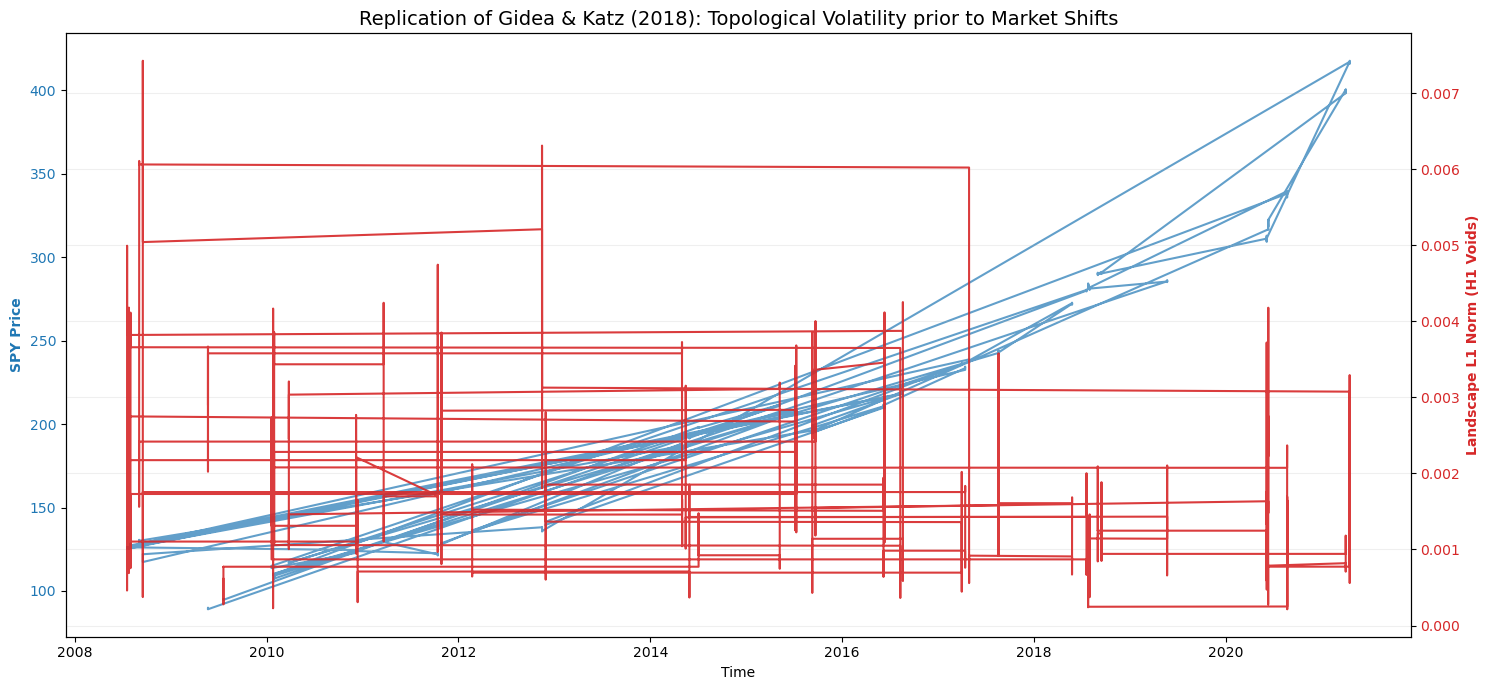

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from gtda.time_series import SingleTakensEmbedding
from gtda.homology import VietorisRipsPersistence
from gtda.diagrams import PersistenceLandscape

# ==========================================
# 1. Data Loading and Preprocessing
# ==========================================
df = pd.read_csv('1_min_SPY_2008-2021.csv', parse_dates=['date'], index_col='date')
df = df.iloc[:20000].copy() 

df['log_ret'] = np.log(df['close'] / df['close'].shift(1))
df.dropna(inplace=True)
data_array = df['log_ret'].values

# ==========================================
# 2. Takens Embedding (Automatic Search)
# ==========================================
# When parameters_type="search", 'time_delay' and 'dimension' act as maximum bounds
embedder = SingleTakensEmbedding(
    parameters_type="search",
    time_delay=20, 
    dimension=3,
    stride=1
)
# embedder = SingleTakensEmbedding(
#     parameters_type="search",
#     time_delay=20, 
#     dimension=10,
#     stride=1
# )

embedder.fit(data_array)
print(f"Optimal parameters found by giotto-tda: tau={embedder.time_delay_}, d={embedder.dimension_}")

embedded_data = embedder.transform(data_array)

# ==========================================
# 3. Persistent Homology & Landscape Extraction
# ==========================================
window_size = 250
n_windows = len(embedded_data) - window_size

# We only calculate H1 (1D loops) as topological voids are the main crash indicator
VR = VietorisRipsPersistence(homology_dimensions=[1], n_jobs=-1)

# Extract only the first layer of the landscape (most prominent topological features)
landscape = PersistenceLandscape(n_bins=100, n_layers=1)

landscape_norms = []
window_dates = []

# Iterating over windows
for i in tqdm(range(n_windows), desc="Processing Landscapes"):
    window_data = embedded_data[i : i+window_size]
    
    # Calculate persistence diagrams for the point cloud
    diagrams = VR.fit_transform([window_data])
    raw_diagram = diagrams[0]
    
    # Inject a dummy H1 feature [birth=0, death=0, dim=1]
    # This prevents errors if a specific window has absolutely no H1 features.
    dummy_h1 = np.array([[0.0, 0.0, 1]])
    
    if raw_diagram.size == 0:
        safe_diagram = dummy_h1
    else:
        safe_diagram = np.vstack((raw_diagram, dummy_h1))
        
    diagrams_reshaped = np.array([safe_diagram])
    
    # Transform diagrams into Persistence Landscapes
    landscapes_arrays = landscape.fit_transform(diagrams_reshaped)
    
    # FIX: landscapes_arrays shape is (n_samples, n_homology_dims * n_layers, n_bins)
    # With 1 sample, 1 dim (H1), and 1 layer, the shape is strictly (1, 1, 100).
    # We extract the first sample [0], the first combined feature [0], and all bins [:]
    current_landscape = landscapes_arrays[0, 0, :] 
    
    # Calculate the L1 Norm (Integral of the landscape curve)
    l1_norm = np.sum(np.abs(current_landscape))
    landscape_norms.append(l1_norm)
    
    # Save the corresponding timestamp
    window_dates.append(df.index[i + window_size])

# ==========================================
# 4. Visualization: Impact of Window Size (Fixed & Smoothed)
# ==========================================

# FIX 1: Ensure the index is strictly a pandas DatetimeIndex 
# This prevents Matplotlib from treating dates as raw overlapping strings
df.index = pd.to_datetime(df.index)

fig, ax1 = plt.subplots(figsize=(16, 8))

# Primary axis: Asset Price
color_price = '#2c3e50'
ax1.set_xlabel('Time')
ax1.set_ylabel('SPY Price', color=color_price, fontweight='bold')

# We align the price plot strictly to the bounds of our evaluated windows
base_dates = results[window_sizes_to_test[0]]['dates']
start_date = base_dates[0]
end_date = base_dates[-1]

mask = (df.index >= start_date) & (df.index <= end_date)
ax1.plot(df.index[mask], df['close'][mask], color=color_price, alpha=0.3, label='SPY Price')
ax1.tick_params(axis='y', labelcolor=color_price)

# Secondary axis: L1 Norms for different window sizes
ax2 = ax1.twinx()  
ax2.set_ylabel('Smoothed Landscape L1 Norm (H1)', color='black', fontweight='bold')  

colors = ['#e74c3c', '#2980b9', '#27ae60', '#8e44ad']

for idx, w_size in enumerate(window_sizes_to_test):
    dates = results[w_size]['dates']
    raw_norms = results[w_size]['norms']
    
    # FIX 2: Apply a moving average (Rolling Mean) to filter out high-frequency 1-minute noise.
    # A window of 20 periods helps reveal the underlying topological trend.
    smoothing_window = 20 
    smoothed_norms = pd.Series(raw_norms).rolling(window=smoothing_window, min_periods=1).mean()
    
    # Normalize the smoothed norms to compare their shapes on the same scale
    normalized_norms = (smoothed_norms - smoothed_norms.mean()) / smoothed_norms.std()
    
    ax2.plot(dates, normalized_norms, color=colors[idx], linewidth=1.5, alpha=0.85, 
             label=f'Norm W={w_size} (Smoothed)')

# Combine legends from both axes
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

# FIX 3: Automatically format and rotate the X-axis date labels to prevent overlap
fig.autofmt_xdate()

plt.title('Impact of Sliding Window Size on Topological Crash Indicators (Noise-Filtered)', fontsize=15)
plt.grid(True, alpha=0.2)
fig.tight_layout()  
plt.show()

Optimal parameters found by giotto-tda: tau=14, d=2
Processing window size: 60


W=60:   0%|          | 0/1993 [00:00<?, ?it/s]

Processing window size: 250


W=250:   0%|          | 0/1974 [00:00<?, ?it/s]

Processing window size: 390


W=390:   0%|          | 0/1960 [00:00<?, ?it/s]

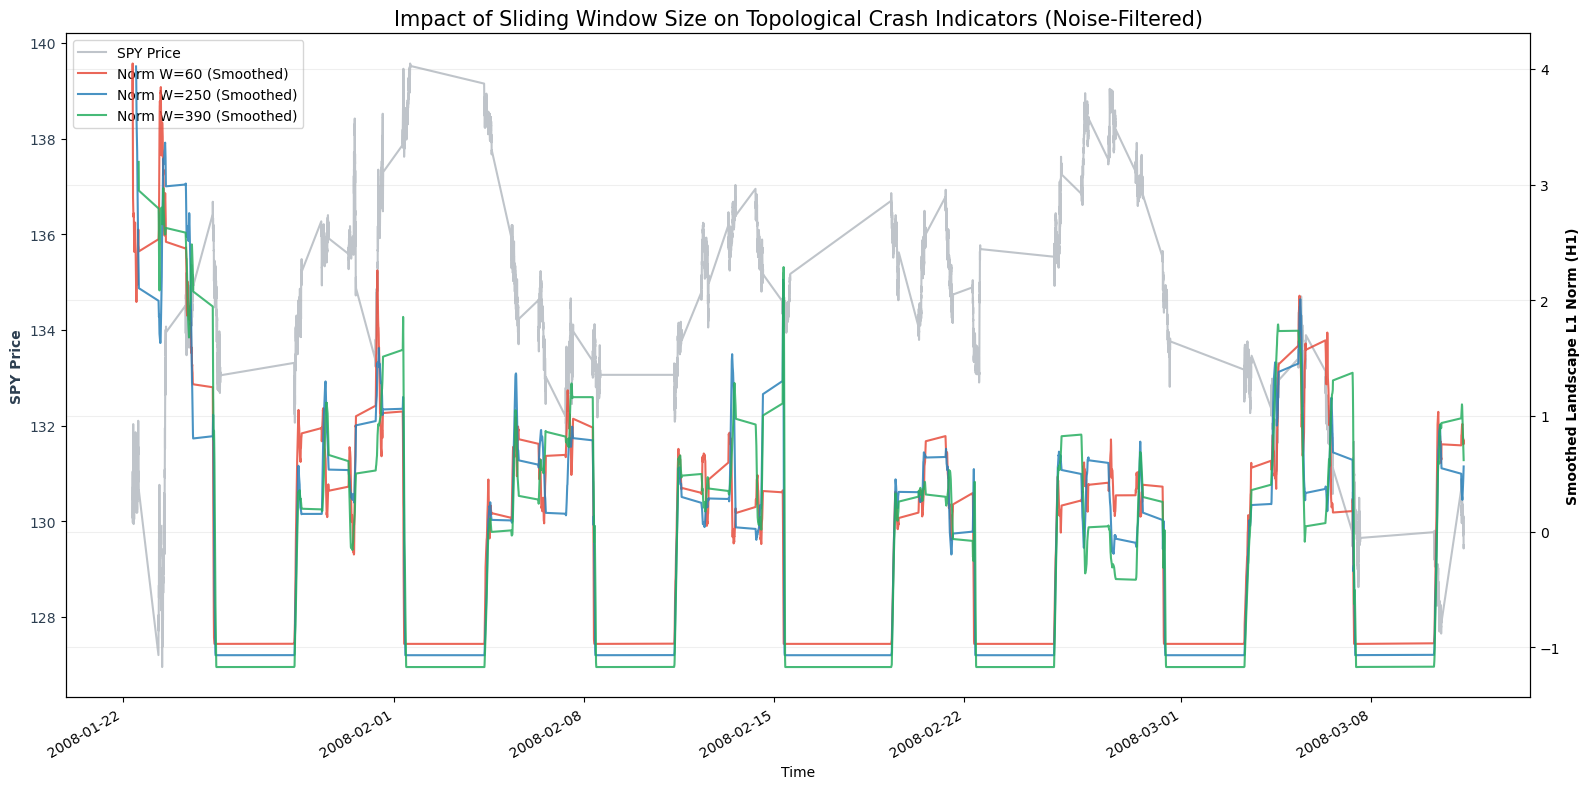

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from gtda.time_series import SingleTakensEmbedding
from gtda.homology import VietorisRipsPersistence
from gtda.diagrams import PersistenceLandscape

# ==========================================
# 1. Data Loading and Preprocessing
# ==========================================
df = pd.read_csv('1_min_SPY_2008-2021.csv', parse_dates=['date'], index_col='date')

# 1. Bezwzględne upewnienie się, że mamy DatetimeIndex
df.index = pd.to_datetime(df.index, errors='coerce')

# 2. TO JEST KLUCZOWE: Wymuszenie chronologii (od najstarszej do najnowszej)
# Bez tego Matplotlib rysuje "pajęczynę" cofając się w czasie
df.sort_index(inplace=True)

# Reszta kodu bez zmian...
df = df.iloc[:20000].copy() 

df['log_ret'] = np.log(df['close'] / df['close'].shift(1))
df.dropna(inplace=True)
data_array = df['log_ret'].values

# ==========================================
# 2. Takens Embedding (Automatic Search)
# ==========================================
embedder = SingleTakensEmbedding(
    parameters_type="search",
    time_delay=20, 
    dimension=3,
    stride=1
)

embedder.fit(data_array)
print(f"Optimal parameters found by giotto-tda: tau={embedder.time_delay_}, d={embedder.dimension_}")

embedded_data = embedder.transform(data_array)

# ==========================================
# 3. Window Size Impact Analysis (Calculations)
# ==========================================
# Define the window sizes to compare
window_sizes_to_test = [60, 250, 390]

VR = VietorisRipsPersistence(homology_dimensions=[1], n_jobs=-1)
landscape = PersistenceLandscape(n_bins=100, n_layers=1)

# THIS is the initialization of the results dictionary missing from the previous snippet
results = {}

for w_size in window_sizes_to_test:
    print(f"Processing window size: {w_size}")
    n_windows = len(embedded_data) - w_size
    
    landscape_norms = []
    window_dates = []
    
    # We use a stride of 10 to speed up execution for demonstration.
    for i in tqdm(range(0, n_windows, 10), desc=f"W={w_size}"):
        window_data = embedded_data[i : i+w_size]
        
        # Calculate persistence diagrams
        diagrams = VR.fit_transform([window_data])
        raw_diagram = diagrams[0]
        
        # Inject dummy H1 feature to prevent shape errors
        dummy_h1 = np.array([[0.0, 0.0, 1]])
        if raw_diagram.size == 0:
            safe_diagram = dummy_h1
        else:
            safe_diagram = np.vstack((raw_diagram, dummy_h1))
            
        diagrams_reshaped = np.array([safe_diagram])
        
        # Transform to Persistence Landscape
        landscapes_arrays = landscape.fit_transform(diagrams_reshaped)
        
        # Extract the first sample, first layer, all bins
        current_landscape = landscapes_arrays[0, 0, :] 
        
        # L1 Norm (Integral)
        l1_norm = np.sum(np.abs(current_landscape))
        landscape_norms.append(l1_norm)
        window_dates.append(df.index[i + w_size])
        
    # Store the arrays in the results dictionary under the current window size key
    results[w_size] = {'dates': window_dates, 'norms': landscape_norms}


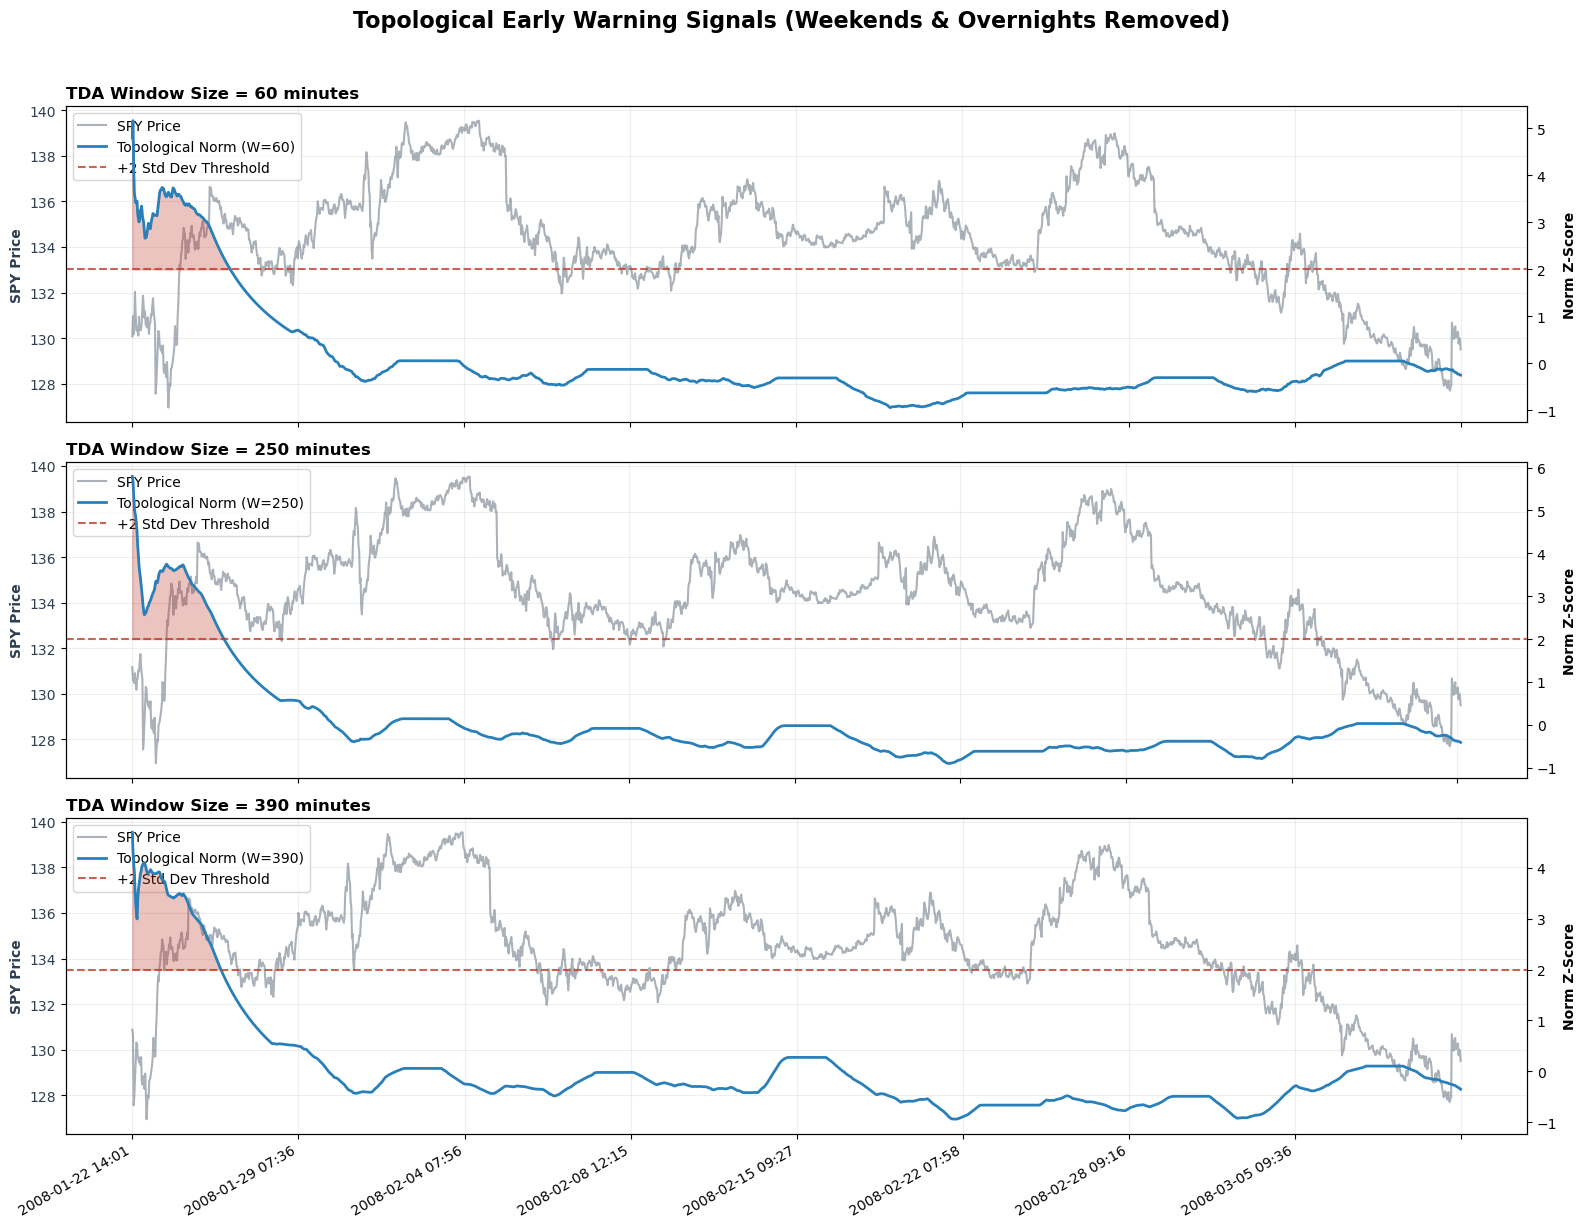

In [ ]:
import matplotlib.ticker as ticker

# ==========================================
# 4. Visualization: Multi-Panel Window Analysis (No Weekend Gaps)
# ==========================================

fig, axes = plt.subplots(nrows=len(window_sizes_to_test), ncols=1, figsize=(16, 12), sharex=False)
color_price = '#2c3e50'
color_signal = '#c0392b' # Strong red for danger signals

# FIX: Remove duplicate timestamps from the dataframe to prevent dimension mismatch
df_clean = df[~df.index.duplicated(keep='last')]

for idx, w_size in enumerate(window_sizes_to_test):
    # Handle single or multiple subplots
    ax1 = axes[idx] if len(window_sizes_to_test) > 1 else axes
    
    dates = results[w_size]['dates']
    raw_norms = results[w_size]['norms']
    
    x_indices = np.arange(len(dates))
    
    # Extract prices using the deduplicated dataframe
    prices = df_clean.loc[dates, 'close'].values
    
    # Plotting Asset Price in the background
    ax1.plot(x_indices, prices, color=color_price, alpha=0.4, label='SPY Price')
    ax1.set_ylabel('SPY Price', color=color_price, fontweight='bold')
    ax1.tick_params(axis='y', labelcolor=color_price)
    
    # Twin axis for the Topological Indicator
    ax2 = ax1.twinx()
    
    # Heavier smoothing for 1-minute high-frequency data (e.g., 250 mins = 1 day)
    smoothing_window = 250 
    smoothed_norms = pd.Series(raw_norms).rolling(window=smoothing_window, min_periods=1).mean()
    
    # Standardize to Z-scores
    mean_norm = smoothed_norms.mean()
    std_norm = smoothed_norms.std()
    z_scores = (smoothed_norms - mean_norm) / std_norm
    
    # Plot the indicator
    ax2.plot(x_indices, z_scores, color='#2980b9', linewidth=2.0, label=f'Topological Norm (W={w_size})')
    
    # Threshold Line (+2 Standard Deviations)
    # threshold = 2.0
    threshold = 1.0
    ax2.axhline(y=threshold, color=color_signal, linestyle='--', linewidth=1.5, alpha=0.8, label='+2 Std Dev Threshold')
    
    # Fill danger zones
    ax2.fill_between(x_indices, z_scores, threshold, where=(z_scores > threshold), 
                     color=color_signal, alpha=0.3, interpolate=True)
    
    ax2.set_ylabel('Norm Z-Score', color='black', fontweight='bold')
    
    # Combine legends
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')
    
    ax1.set_title(f'TDA Window Size = {w_size} minutes', fontsize=12, fontweight='bold', loc='left')
    ax1.grid(True, alpha=0.2)
    
    # X-Axis Formatting: Map the integers back to readable Date strings
    num_ticks = 8 # Number of dates we want to show on the X axis
    tick_spacing = max(1, len(dates) // num_ticks)
    
    ax1.xaxis.set_major_locator(ticker.MultipleLocator(tick_spacing))
    formatted_dates = [d.strftime('%Y-%m-%d %H:%M') for d in dates]
    
    def format_date(x, pos=None):
        if 0 <= int(x) < len(formatted_dates):
            return formatted_dates[int(x)]
        return ""
        
    ax1.xaxis.set_major_formatter(ticker.FuncFormatter(format_date))

# Final layout adjustments
fig.autofmt_xdate()
plt.suptitle('Topological Early Warning Signals (Weekends & Overnights Removed)', fontsize=16, fontweight='bold', y=1.02)
fig.tight_layout()
plt.show()

In [26]:
df.head()


,Unnamed: 0,open,high,low,close,volume,barCount,average,log_ret
date,,,,,,,,,
2009-05-22 07:31:00,1,89.38,89.53,89.37,89.50,5336,1938,89.468,0.001454
2009-05-22 07:32:00,2,89.51,89.54,89.48,89.49,3349,1184,89.516,-0.000112
2009-05-22 07:33:00,3,89.49,89.49,89.31,89.34,3495,1240,89.386,-0.001678
2009-05-22 07:34:00,4,89.33,89.46,89.33,89.39,9731,2637,89.379,0.000560
2009-05-22 07:35:00,5,89.38,89.41,89.17,89.18,8546,2366,89.273,-0.002352


[*********************100%***********************]  4 of 4 completed

Pobieranie danych...
Wygenerowano 2969 chmur punktów, każda o kształcie (50, 4)
Obliczanie homologii i norm L1/L2...


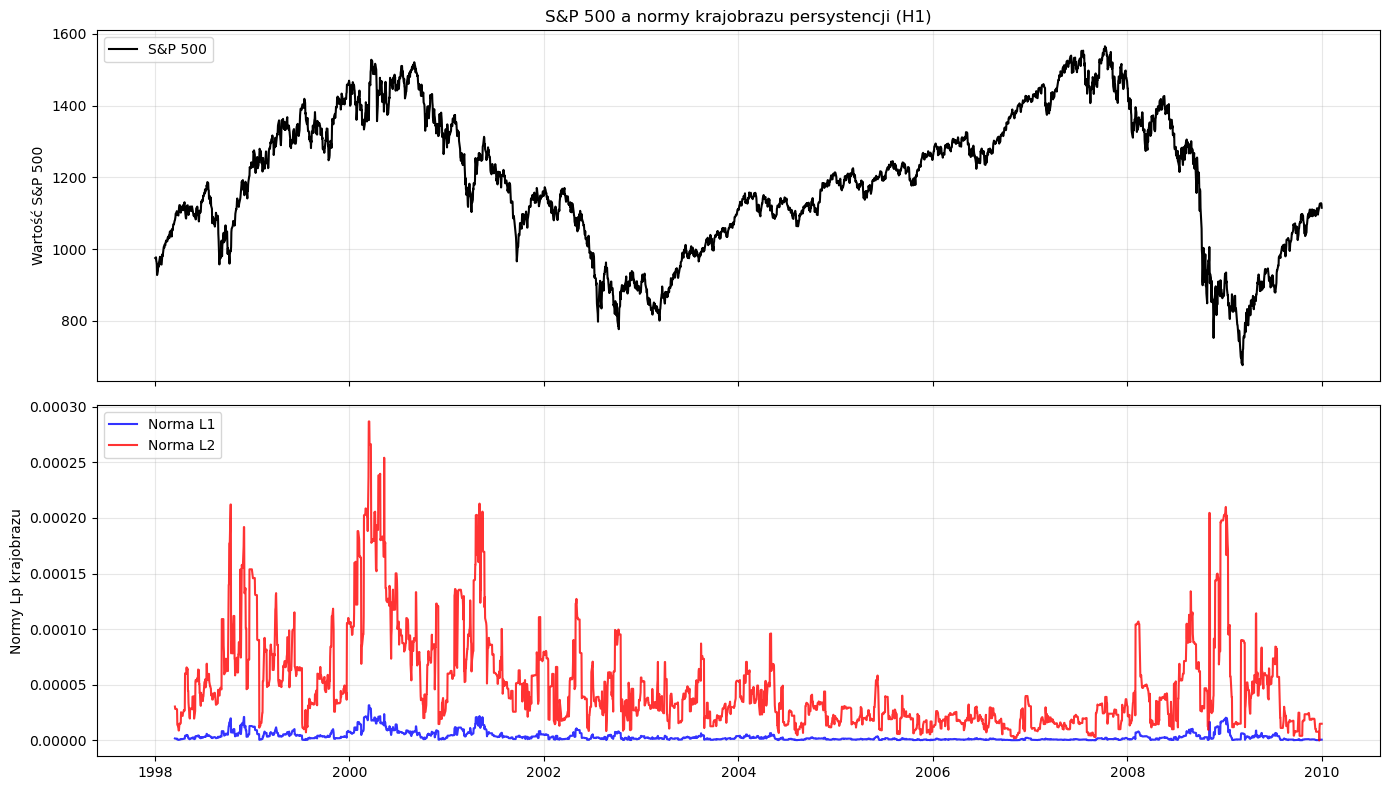

In [3]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from gtda.time_series import SlidingWindow
from gtda.homology import VietorisRipsPersistence
from gtda.diagrams import Amplitude
from sklearn.pipeline import Pipeline

# 1. Pobranie danych dla 4 głównych indeksów (S&P 500, DJIA, NASDAQ, Russell 2000)
tickers = ['^GSPC', '^DJI', '^IXIC', '^RUT']
print("Pobieranie danych...")
# data = yf.download(tickers, start="1998-01-01", end="2010-01-01")['Adj Close']

raw_data = yf.download(tickers, start="1998-01-01", end="2010-01-01")
data = raw_data['Close'] # lub raw_data.xs('Adj Close', level=0, axis=1) jeśli Adj Close istnieje

# Usunięcie braków danych i wyliczenie log-zwrotów
data = data.dropna()
log_returns = np.log(data / data.shift(1)).dropna()

# 2. Utworzenie okien przesuwnych
window_size = 50

# SlidingWindow dzieli szereg 4D na chmury punktów o rozmiarze (w, d) -> (50, 4)
SW = SlidingWindow(size=window_size, stride=1)
X = SW.fit_transform(log_returns.values)
print(f"Wygenerowano {X.shape[0]} chmur punktów, każda o kształcie {X.shape[1:]}")

# 3. Definicja potoków (Pipelines) do analizy TDA
# Interesują nas tylko pętle, stąd homology_dimensions=[1]
# Klasa Amplitude z metryką 'landscape' wylicza od razu normę krajobrazu persystencji
tda_pipeline_l1 = Pipeline([
    ('rips', VietorisRipsPersistence(homology_dimensions=[1], n_jobs=-1)),
    ('amplitude_l1', Amplitude(metric='landscape', metric_params={'p': 1}, n_jobs=-1))
])

tda_pipeline_l2 = Pipeline([
    ('rips', VietorisRipsPersistence(homology_dimensions=[1], n_jobs=-1)),
    ('amplitude_l2', Amplitude(metric='landscape', metric_params={'p': 2}, n_jobs=-1))
])

# 4. Obliczenia (mogą chwilę potrwać dla kilku tysięcy chmur punktów)
print("Obliczanie homologii i norm L1/L2...")
l1_norms = tda_pipeline_l1.fit_transform(X).flatten()
l2_norms = tda_pipeline_l2.fit_transform(X).flatten()

# 5. Przygotowanie osi czasu do wykresu (odrzucamy dni z pierwszego okna)
time_index = log_returns.index[window_size - 1:]

# 6. Wizualizacja wyników
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Wykres S&P 500 jako tło rynkowe
ax1.plot(data.index, data['^GSPC'], color='black', label='S&P 500')
ax1.set_ylabel('Wartość S&P 500')
ax1.set_title('S&P 500 a normy krajobrazu persystencji (H1)')
ax1.legend(loc='upper left')
ax1.grid(alpha=0.3)

# Wykres norm krajobrazów
ax2.plot(time_index, l1_norms, color='blue', alpha=0.8, label='Norma L1')
ax2.plot(time_index, l2_norms, color='red', alpha=0.8, label='Norma L2')
ax2.set_ylabel('Normy Lp krajobrazu')
ax2.legend(loc='upper left')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.signal import welch
from tqdm.notebook import tqdm
from gtda.time_series import SingleTakensEmbedding
from gtda.homology import VietorisRipsPersistence
from gtda.diagrams import PersistenceLandscape

# ==========================================
# 1. Data Loading and Preprocessing
# ==========================================
df = pd.read_csv('1_min_SPY_2008-2021.csv', parse_dates=['date'], index_col='date')
df.index = pd.to_datetime(df.index, errors='coerce')
df.sort_index(inplace=True)

# Remove duplicates immediately to avoid loc issues later
df_clean = df[~df.index.duplicated(keep='last')].copy()

# Slice for testing (adjust as needed)
df_sample = df_clean.iloc[:20000].copy()
df_sample['log_ret'] = np.log(df_sample['close'] / df_sample['close'].shift(1))
df_sample.dropna(inplace=True)
data_array = df_sample['log_ret'].values

# ==========================================
# 2. Takens Embedding
# ==========================================
embedder = SingleTakensEmbedding(parameters_type="search", time_delay=20, dimension=3, stride=1)
embedder.fit(data_array)
embedded_data = embedder.transform(data_array)

# ==========================================
# 3. TDA Processing (Rebuilding the lost 'results')
# ==========================================
w_size = 250
VR = VietorisRipsPersistence(homology_dimensions=[1], n_jobs=-1)
landscape = PersistenceLandscape(n_bins=100, n_layers=1)

n_windows = len(embedded_data) - w_size
landscape_norms = []
window_dates = []

for i in tqdm(range(0, n_windows, 10), desc=f"VR Loop W={w_size}"):
    window_data = embedded_data[i : i+w_size]
    
    diagrams = VR.fit_transform([window_data])
    raw_diagram = diagrams[0]
    
    # Dummy H1 injection
    dummy_h1 = np.array([[0.0, 0.0, 1]])
    safe_diagram = dummy_h1 if raw_diagram.size == 0 else np.vstack((raw_diagram, dummy_h1))
        
    landscapes_arrays = landscape.fit_transform(np.array([safe_diagram]))
    l1_norm = np.sum(np.abs(landscapes_arrays[0, 0, :]))
    
    landscape_norms.append(l1_norm)
    window_dates.append(df_sample.index[i + w_size])

# Initialize the time series of norms
norms_series = pd.Series(landscape_norms, index=window_dates)

# ==========================================
# 4. EWS Calculations (Critical Slowing Down)
# ==========================================
ews_window = 500 

rolling_variance = norms_series.rolling(window=ews_window).var()

def low_freq_spectral_density(window_data):
    valid_data = window_data[~np.isnan(window_data)]
    if len(valid_data) < ews_window:
        return np.nan
    
    freqs, psd = welch(valid_data, nperseg=250) 
    low_freq_mask = freqs < np.percentile(freqs, 25)
    return np.mean(psd[low_freq_mask])

rolling_spectrum = norms_series.rolling(window=ews_window).apply(low_freq_spectral_density, raw=True)

# Standardize
rolling_variance_z = (rolling_variance - rolling_variance.mean()) / rolling_variance.std()
rolling_spectrum_z = (rolling_spectrum - rolling_spectrum.mean()) / rolling_spectrum.std()

# ==========================================
# 5. Final EWS Panel Visualization
# ==========================================
valid_idx = rolling_variance_z.dropna().index

price_data = df_sample.loc[valid_idx, 'close']
var_data = rolling_variance_z.loc[valid_idx]
spec_data = rolling_spectrum_z.loc[valid_idx]
x_indices = np.arange(len(valid_idx))

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
color_signal = '#c0392b'

# Plot 1: SPY Price
ax1.plot(x_indices, price_data.values, color='#2c3e50', linewidth=1.5, label='SPY Price (1-min)')
ax1.set_ylabel('SPY Price', fontweight='bold')
ax1.set_title(f'EWS: Topological Analysis of SPY (Takens d={embedder.dimension_}, tau={embedder.time_delay_}, Rips w={w_size})', loc='left', fontweight='bold', fontsize=14)
ax1.legend(loc='upper left')
ax1.grid(alpha=0.3)

# Plot 2: L1 Norm Variance
ax2.plot(x_indices, var_data.values, color='purple', linewidth=2.0, label='Rolling Variance (Z-score)')
ax2.axhline(y=2.0, color=color_signal, linestyle='--', linewidth=1.5, alpha=0.8, label='+2 Std Dev Threshold')
ax2.fill_between(x_indices, var_data.values, 2.0, where=(var_data.values > 2.0), color='purple', alpha=0.3)
ax2.set_ylabel('L1 Variance', fontweight='bold')
ax2.legend(loc='upper left')
ax2.grid(alpha=0.3)

# Plot 3: Spectral Density (Low Frequencies)
ax3.plot(x_indices, spec_data.values, color='darkorange', linewidth=2.0, label='Low-Freq Spectrum (Z-score)')
ax3.axhline(y=2.0, color=color_signal, linestyle='--', linewidth=1.5, alpha=0.8, label='+2 Std Dev Threshold')
ax3.fill_between(x_indices, spec_data.values, 2.0, where=(spec_data.values > 2.0), color='darkorange', alpha=0.3)
ax3.set_ylabel('Spectral Density', fontweight='bold')
ax3.legend(loc='upper left')
ax3.grid(alpha=0.3)

# X-Axis Formatting
num_ticks = 8
tick_spacing = max(1, len(valid_idx) // num_ticks)
ax3.xaxis.set_major_locator(ticker.MultipleLocator(tick_spacing))

formatted_dates = [d.strftime('%Y-%m-%d %H:%M') for d in valid_idx]
def format_date(x, pos=None):
    if 0 <= int(x) < len(formatted_dates):
        return formatted_dates[int(x)]
    return ""

ax3.xaxis.set_major_formatter(ticker.FuncFormatter(format_date))

plt.tight_layout()
plt.show()

VR Loop W=250:   0%|          | 0/1974 [00:00<?, ?it/s]

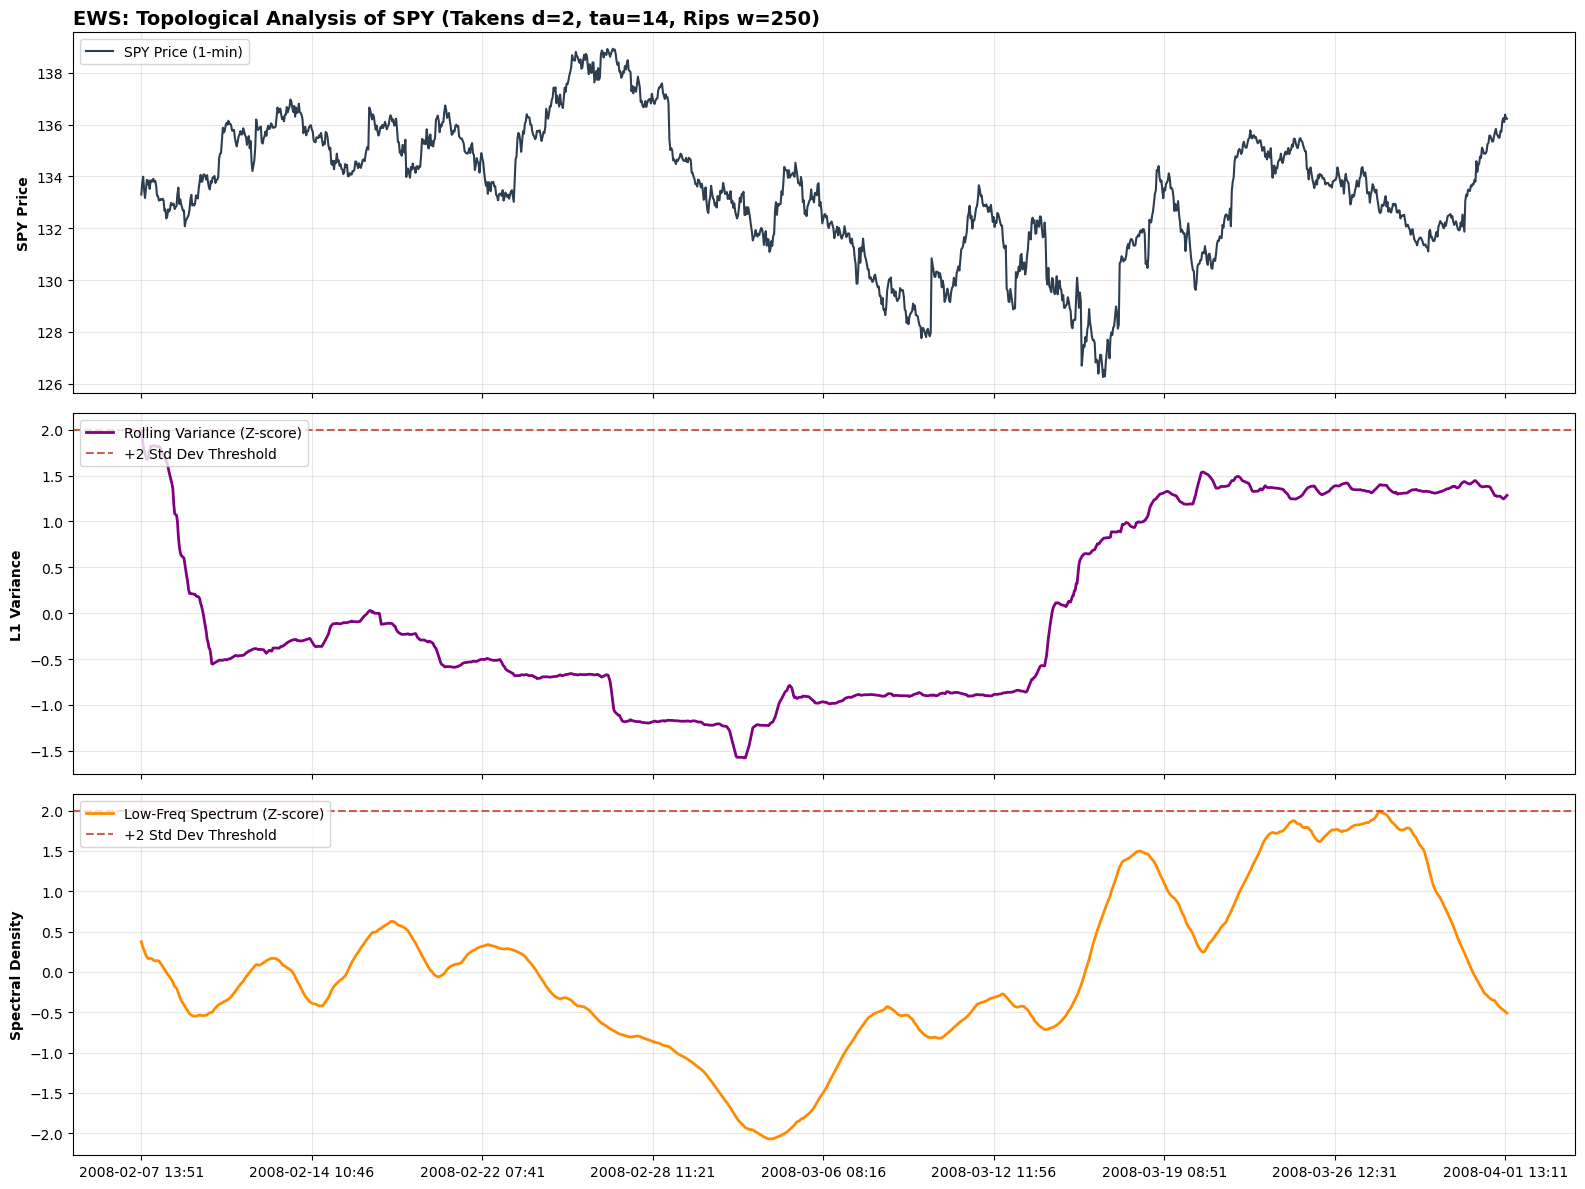

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.signal import welch
from tqdm.notebook import tqdm
from gtda.time_series import SingleTakensEmbedding
from gtda.homology import VietorisRipsPersistence
from gtda.diagrams import PersistenceLandscape

# ==========================================
# 1. Data Loading and Preprocessing
# ==========================================
df = pd.read_csv('1_min_SPY_2008-2021.csv', parse_dates=['date'], index_col='date')
df.index = pd.to_datetime(df.index, errors='coerce')
df.sort_index(inplace=True)

# Remove duplicates immediately to avoid loc issues later
df_clean = df[~df.index.duplicated(keep='last')].copy()

# Slice for testing (adjust as needed)
df_sample = df_clean.iloc[:20000].copy()
df_sample['log_ret'] = np.log(df_sample['close'] / df_sample['close'].shift(1))
df_sample.dropna(inplace=True)
data_array = df_sample['log_ret'].values

# ==========================================
# 2. Takens Embedding
# ==========================================
embedder = SingleTakensEmbedding(parameters_type="search", time_delay=20, dimension=3, stride=1)
embedder.fit(data_array)
embedded_data = embedder.transform(data_array)

# ==========================================
# 3. TDA Processing (Rebuilding the lost 'results')
# ==========================================
w_size = 250
VR = VietorisRipsPersistence(homology_dimensions=[1], n_jobs=-1)
landscape = PersistenceLandscape(n_bins=100, n_layers=1)

n_windows = len(embedded_data) - w_size
landscape_norms = []
window_dates = []

for i in tqdm(range(0, n_windows, 10), desc=f"VR Loop W={w_size}"):
    window_data = embedded_data[i : i+w_size]
    
    diagrams = VR.fit_transform([window_data])
    raw_diagram = diagrams[0]
    
    # Dummy H1 injection
    dummy_h1 = np.array([[0.0, 0.0, 1]])
    safe_diagram = dummy_h1 if raw_diagram.size == 0 else np.vstack((raw_diagram, dummy_h1))
        
    landscapes_arrays = landscape.fit_transform(np.array([safe_diagram]))
    l1_norm = np.sum(np.abs(landscapes_arrays[0, 0, :]))
    
    landscape_norms.append(l1_norm)
    window_dates.append(df_sample.index[i + w_size])

# Initialize the time series of norms
norms_series = pd.Series(landscape_norms, index=window_dates)

# ==========================================
# 4. EWS Calculations (Critical Slowing Down)
# ==========================================
ews_window = 500 

rolling_variance = norms_series.rolling(window=ews_window).var()

def low_freq_spectral_density(window_data):
    valid_data = window_data[~np.isnan(window_data)]
    if len(valid_data) < ews_window:
        return np.nan
    
    freqs, psd = welch(valid_data, nperseg=250) 
    low_freq_mask = freqs < np.percentile(freqs, 25)
    return np.mean(psd[low_freq_mask])

rolling_spectrum = norms_series.rolling(window=ews_window).apply(low_freq_spectral_density, raw=True)

# Standardize
rolling_variance_z = (rolling_variance - rolling_variance.mean()) / rolling_variance.std()
rolling_spectrum_z = (rolling_spectrum - rolling_spectrum.mean()) / rolling_spectrum.std()

# ==========================================
# 5. Final EWS Panel Visualization
# ==========================================
valid_idx = rolling_variance_z.dropna().index

price_data = df_sample.loc[valid_idx, 'close']
var_data = rolling_variance_z.loc[valid_idx]
spec_data = rolling_spectrum_z.loc[valid_idx]
x_indices = np.arange(len(valid_idx))

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
color_signal = '#c0392b'

# Plot 1: SPY Price
ax1.plot(x_indices, price_data.values, color='#2c3e50', linewidth=1.5, label='SPY Price (1-min)')
ax1.set_ylabel('SPY Price', fontweight='bold')
ax1.set_title(f'EWS: Topological Analysis of SPY (Takens d={embedder.dimension_}, tau={embedder.time_delay_}, Rips w={w_size})', loc='left', fontweight='bold', fontsize=14)
ax1.legend(loc='upper left')
ax1.grid(alpha=0.3)

# Plot 2: L1 Norm Variance
ax2.plot(x_indices, var_data.values, color='purple', linewidth=2.0, label='Rolling Variance (Z-score)')
ax2.axhline(y=2.0, color=color_signal, linestyle='--', linewidth=1.5, alpha=0.8, label='+2 Std Dev Threshold')
ax2.fill_between(x_indices, var_data.values, 2.0, where=(var_data.values > 2.0), color='purple', alpha=0.3)
ax2.set_ylabel('L1 Variance', fontweight='bold')
ax2.legend(loc='upper left')
ax2.grid(alpha=0.3)

# Plot 3: Spectral Density (Low Frequencies)
ax3.plot(x_indices, spec_data.values, color='darkorange', linewidth=2.0, label='Low-Freq Spectrum (Z-score)')
ax3.axhline(y=2.0, color=color_signal, linestyle='--', linewidth=1.5, alpha=0.8, label='+2 Std Dev Threshold')
ax3.fill_between(x_indices, spec_data.values, 2.0, where=(spec_data.values > 2.0), color='darkorange', alpha=0.3)
ax3.set_ylabel('Spectral Density', fontweight='bold')
ax3.legend(loc='upper left')
ax3.grid(alpha=0.3)

# X-Axis Formatting
num_ticks = 8
tick_spacing = max(1, len(valid_idx) // num_ticks)
ax3.xaxis.set_major_locator(ticker.MultipleLocator(tick_spacing))

formatted_dates = [d.strftime('%Y-%m-%d %H:%M') for d in valid_idx]
def format_date(x, pos=None):
    if 0 <= int(x) < len(formatted_dates):
        return formatted_dates[int(x)]
    return ""

ax3.xaxis.set_major_formatter(ticker.FuncFormatter(format_date))

plt.tight_layout()
plt.show()

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.signal import welch
from tqdm.notebook import tqdm
from gtda.time_series import SingleTakensEmbedding
from gtda.homology import VietorisRipsPersistence
from gtda.diagrams import PersistenceLandscape

# ==========================================
# 1. Data Prep (Strictly Date-Based)
# ==========================================
df = pd.read_csv('1_min_SPY_2008-2021.csv', parse_dates=['date'], index_col='date')
df.index = pd.to_datetime(df.index, errors='coerce')
df.sort_index(inplace=True)

df_clean = df[~df.index.duplicated(keep='last')].copy()

start = '2008-01-01'
end = '2021-12-31'
# 1. Slice strictly by date. Make sure there is NO .iloc[:20000] anywhere after this!
df_sample = df_clean.loc[start:end].copy() 

df_sample['log_ret'] = np.log(df_sample['close'] / df_sample['close'].shift(1))
df_sample.dropna(inplace=True)
data_array = df_sample['log_ret'].values


# ==========================================
# 2. Phase Space Reconstruction (Takens)
# ==========================================
embedder = SingleTakensEmbedding(parameters_type="search", time_delay=100, dimension=5, stride=1)
embedder.fit(data_array)
embedded_data = embedder.transform(data_array)

# ==========================================
# 3. Topological Feature Extraction (Optimized Stride)
# ==========================================
w_size = 250
VR = VietorisRipsPersistence(homology_dimensions=[1], n_jobs=-1)
landscape = PersistenceLandscape(n_bins=100, n_layers=1)

n_windows = len(embedded_data) - w_size
landscape_norms = []
window_dates = []

# INCREASED STRIDE from 10 to 30 to speed up processing for larger date ranges
# eval_step = 720000 
eval_step = 30

for i in tqdm(range(0, n_windows, eval_step), desc=f"TDA Pipeline (W={w_size})"):
    window_data = embedded_data[i : i+w_size]
    diagrams = VR.fit_transform([window_data])
    raw_diagram = diagrams[0]
    
    dummy_h1 = np.array([[0.0, 0.0, 1]])
    safe_diagram = dummy_h1 if raw_diagram.size == 0 else np.vstack((raw_diagram, dummy_h1))
        
    landscapes_arrays = landscape.fit_transform(np.array([safe_diagram]))
    l1_norm = np.sum(np.abs(landscapes_arrays[0, 0, :]))
    
    landscape_norms.append(l1_norm)
    window_dates.append(df_sample.index[i + w_size])

norms_series = pd.Series(landscape_norms, index=window_dates)

# ==========================================
# 4. EWS Calculations 
# ==========================================
eval_step = 30

# Uwaga: parametry rolling dostosuj w zależności od tego, czy zresamplujesz do 1D.
# 10000/390 = 25,6 trading days
ews_window_minutes = 10000 
# ews_window_minutes = 144000 
rolling_elements = max(1, ews_window_minutes // eval_step)

rolling_variance = norms_series.rolling(window=rolling_elements).var()

def low_freq_spectral_density(window_data):
    valid_data = window_data[~np.isnan(window_data)]
    if len(valid_data) < rolling_elements:
        return np.nan
    
    segment_length = min(250, len(valid_data) // 2)
    freqs, psd = welch(valid_data, nperseg=segment_length) 
    
    low_freq_mask = freqs < np.percentile(freqs, 25)
    return np.mean(psd[low_freq_mask])

rolling_spectrum = norms_series.rolling(window=rolling_elements).apply(low_freq_spectral_density, raw=True)

# -------- KLUCZOWA POPRAWKA --------
# Okno 3x większe od ews_window, by zapewnić historyczną bazę odniesienia
z_score_window = rolling_elements * 12 

# Dynamiczny (kroczący) Z-Score
var_z = (rolling_variance - rolling_variance.rolling(window=z_score_window).mean()) / rolling_variance.rolling(window=z_score_window).std()

spec_z = (rolling_spectrum - rolling_spectrum.rolling(window=z_score_window).mean()) / rolling_spectrum.rolling(window=z_score_window).std()
# ------------------------------------

# Powracamy do rozsądnego progu detekcji krachu 
THRESHOLD = 2.0 

composite_alarm = (var_z > THRESHOLD) & (spec_z > THRESHOLD)

# ==========================================
# 5. Advanced Visualization
# ==========================================
valid_idx = var_z.dropna().index
price_data = df_sample.loc[valid_idx, 'close']
var_data = var_z.loc[valid_idx]
spec_data = spec_z.loc[valid_idx]
alarm_data = composite_alarm.loc[valid_idx]
x_indices = np.arange(len(valid_idx))

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
color_alarm = '#c0392b' # Deep red

# Panel 1: Price Action with Topology Alarm Overlay
ax1.plot(x_indices, price_data.values, color='#2c3e50', linewidth=1.5, label='SPY Intraday Price')
# Shading the background where the topological alarm is triggered
ax1.fill_between(x_indices, price_data.min(), price_data.max(), 
                 where=alarm_data.values, color=color_alarm, alpha=0.2, label='EWS Triggered (Crash Warning)')
ax1.set_ylabel('Price', fontweight='bold')
ax1.set_title(f'Topological Early Warning System (Takens d={embedder.dimension_}, tau={embedder.time_delay_})', loc='left', fontweight='bold', fontsize=14)
ax1.legend(loc='upper left')
ax1.grid(alpha=0.3)

# Panel 2: Variance
ax2.plot(x_indices, var_data.values, color='purple', linewidth=2.0, label='L1 Norm Variance (Z-Score)')
ax2.axhline(y=THRESHOLD, color='gray', linestyle='--', linewidth=1.5, label=f'Warning Threshold (+{THRESHOLD} Std Dev)')
ax2.fill_between(x_indices, var_data.values, THRESHOLD, where=(var_data.values > THRESHOLD), color='purple', alpha=0.3)
ax2.set_ylabel('Variance', fontweight='bold')
ax2.set_ylim([-2, max(5, var_data.max() * 1.1)]) # Scale fix
ax2.legend(loc='upper left')
ax2.grid(alpha=0.3)

# Panel 3: Low-Frequency Spectrum
ax3.plot(x_indices, spec_data.values, color='darkorange', linewidth=2.0, label='Low-Freq Spectral Density (Z-Score)')
ax3.axhline(y=THRESHOLD, color='gray', linestyle='--', linewidth=1.5, label=f'Warning Threshold (+{THRESHOLD} Std Dev)')
ax3.fill_between(x_indices, spec_data.values, THRESHOLD, where=(spec_data.values > THRESHOLD), color='darkorange', alpha=0.3)
ax3.set_ylabel('Spectral Density', fontweight='bold')
ax3.set_ylim([-2, max(5, spec_data.max() * 1.1)]) # Scale fix
ax3.legend(loc='upper left')
ax3.grid(alpha=0.3)

# Axis Formatting
num_ticks = 8
tick_spacing = max(1, len(valid_idx) // num_ticks)
ax3.xaxis.set_major_locator(ticker.MultipleLocator(tick_spacing))

formatted_dates = [d.strftime('%Y-%m-%d %H:%M') for d in valid_idx]
def format_date(x, pos=None):
    if 0 <= int(x) < len(formatted_dates):
        return formatted_dates[int(x)]
    return ""

ax3.xaxis.set_major_formatter(ticker.FuncFormatter(format_date))
fig.autofmt_xdate()

plt.tight_layout()
plt.savefig(f'from_{start}_to_{end}_topological_ews_final_{w_size}_{ews_window_minutes}_12rolling.png', dpi=300)
plt.show()

KeyboardInterrupt: 

[*********************100%***********************]  4 of 4 completed


Pobieranie danych z Yahoo Finance...
Uruchamianie wielowymiarowego pipeline TDA (Okno=50 dni)...


100%|██████████| 3725/3725 [00:52<00:00, 71.44it/s]


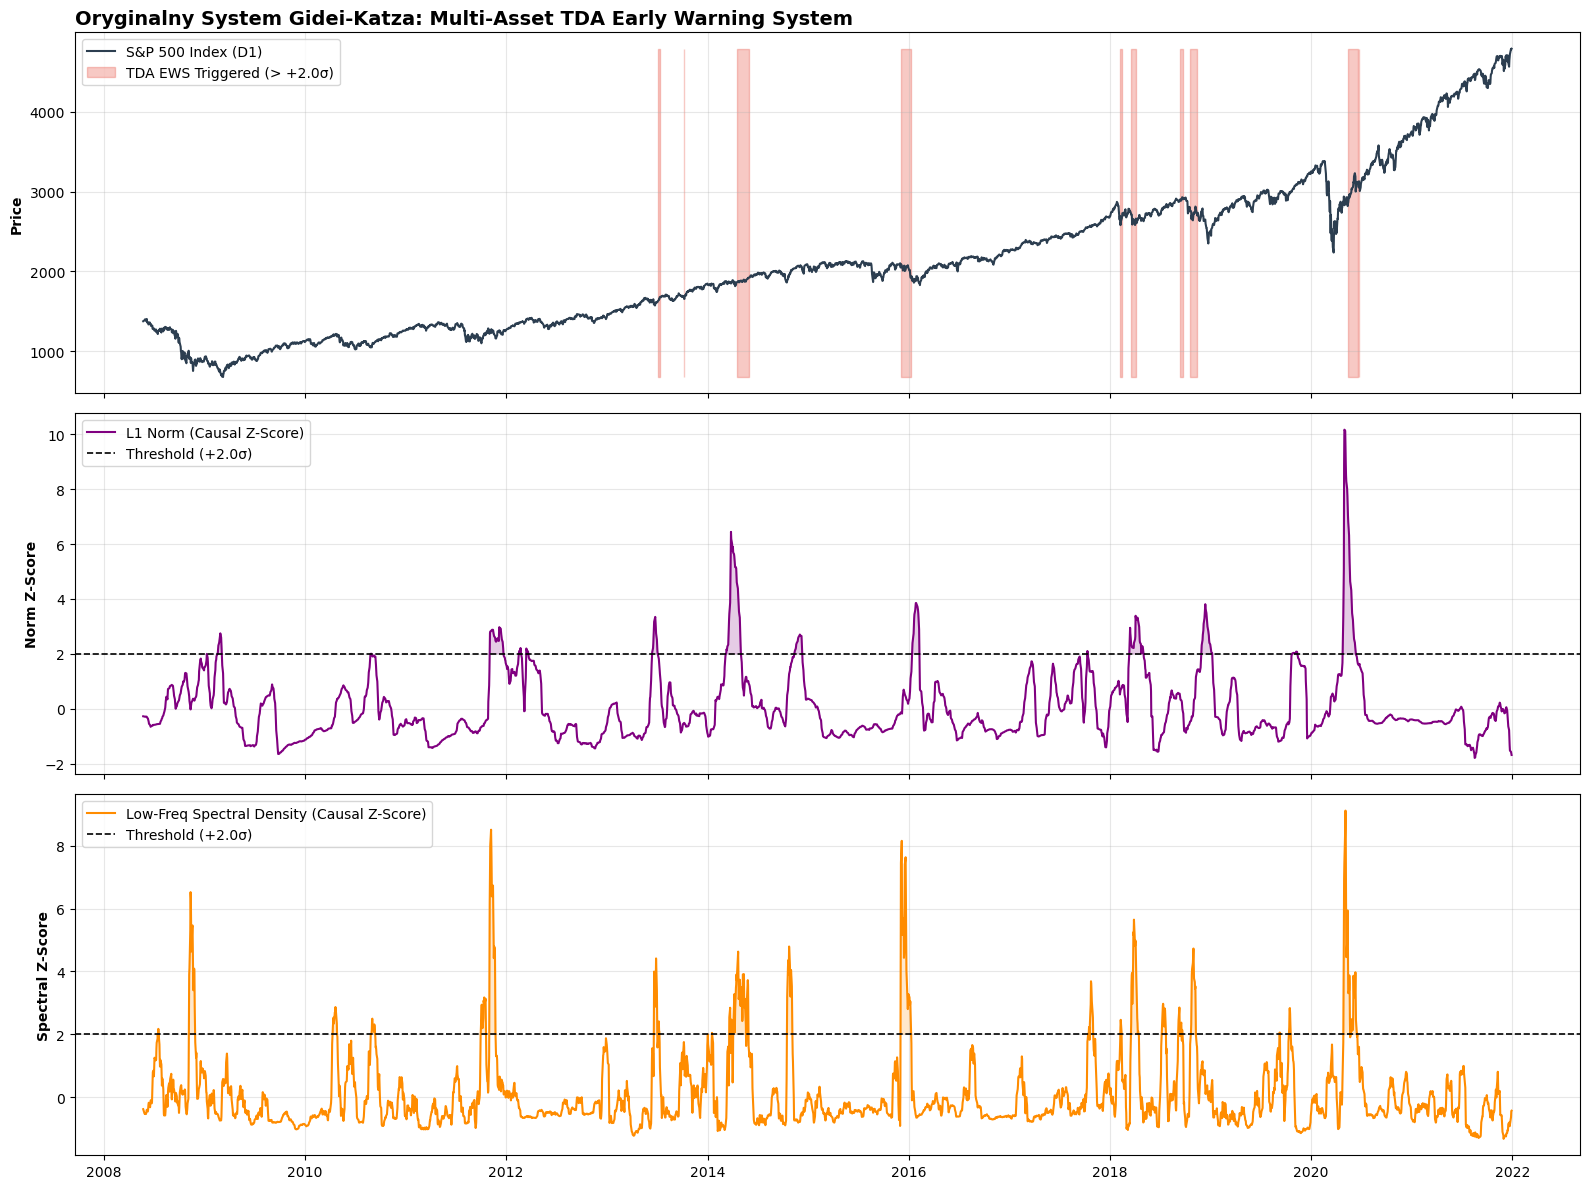

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import yfinance as yf
from scipy.signal import welch
from tqdm import tqdm
from gtda.homology import VietorisRipsPersistence
from gtda.diagrams import PersistenceLandscape

# ==========================================
# 1. Pobieranie i Przygotowanie Danych (Multi-Asset)
# ==========================================
# ^GSPC = S&P 500, ^DJI = Dow Jones, ^IXIC = NASDAQ, ^RUT = Russell 2000
tickers = ['^GSPC', '^DJI', '^IXIC', '^RUT']
start_date = '2007-01-01'  # Zaczynamy rok wcześniej, żeby mieć bazę pod Z-Score na start 2008
end_date = '2021-12-31'

print("Pobieranie danych z Yahoo Finance...")
df_raw = yf.download(tickers, start=start_date, end=end_date)['Close']

# Obliczanie logarytmicznych stóp zwrotu i czyszczenie danych
df_rets = np.log(df_raw / df_raw.shift(1)).dropna()

# Chmura punktów to po prostu macierz stóp zwrotu (N_dni x 4_indeksy)
# Każdy dzień to punkt w R^4
data_matrix = df_rets.values
dates_vector = df_rets.index

# ==========================================
# 2. Topologiczna Ekstrakcja Cech (Okno kroczące w R^4)
# ==========================================
# w_size = 60       # Okno ok. 3 miesięcy handlowych (Gidea & Katz używali krótszych okien dla danych D1)
w_size = 50       # Okno ok. 3 miesięcy handlowych (Gidea & Katz używali krótszych okien dla danych D1)

eval_step = 1     # Przy danych dziennych możemy liczyć dzień po dniu (brak luku informacyjnego)

VR = VietorisRipsPersistence(homology_dimensions=[1], n_jobs=-1)
landscape = PersistenceLandscape(n_bins=100, n_layers=1)

n_windows = len(data_matrix) - w_size
landscape_norms = []
window_dates = []

print(f"Uruchamianie wielowymiarowego pipeline TDA (Okno={w_size} dni)...")
for i in tqdm(range(0, n_windows, eval_step)):
    # Wycinamy okno czasowe zawierające punkty z 4 indeksów simultanicznie
    window_data = data_matrix[i : i + w_size]  # Kształt: (w_size, 4)
    
    # TDA na naturalnej chmurze punktów
    diagrams = VR.fit_transform([window_data])
    raw_diagram = diagrams[0]
    
    # Zabezpieczenie przed pustym diagramem
    dummy_h1 = np.array([[0.0, 0.0, 1]])
    safe_diagram = dummy_h1 if raw_diagram.size == 0 else np.vstack((raw_diagram, dummy_h1))
    
    # Krajobraz persystentny i norma L1
    landscapes_arrays = landscape.fit_transform(np.array([safe_diagram]))
    l1_norm = np.sum(np.abs(landscapes_arrays[0, 0, :]))
    
    landscape_norms.append(l1_norm)
    window_dates.append(dates_vector[i + w_size - 1])

norms_series = pd.Series(landscape_norms, index=window_dates)

# S&P 500 jako indeks referencyjny do wykresu ceny
spy_price = df_raw['^GSPC'].loc[norms_series.index]

# ==========================================
# 3. Przyczynowe Kalkulacje EWS (Bez Look-Ahead Bias)
# ==========================================
# ews_window = 40       # Okno wariancji i spektrum (ok. 2 miesiące handlowe)
ews_window = 100       # Okno wariancji i spektrum (ok. 2 miesiące handlowe)
z_score_window = 252  # Okno historyczne do średniej i std dla Z-Score (1 rok handlowy)

smooth_norm = norms_series.rolling(window=ews_window).mean()

# Causal Z-Score dla SAMEJ NORMY L1
norm_mean = smooth_norm.rolling(window=z_score_window).mean()
norm_std = smooth_norm.rolling(window=z_score_window).std()
norm_z = (smooth_norm - norm_mean) / norm_std

# Dla spektrum używamy mniejszego segmentu, adekwatnego do mniejszego okna
def low_freq_spectral_density(window_data):
    valid_data = window_data[~np.isnan(window_data)]
    if len(valid_data) < 15:  # dopasowane do krótszego w_size
        return np.nan
    freqs, psd = welch(valid_data, nperseg=10)
    low_freq_mask = freqs < np.percentile(freqs, 30)
    return np.mean(psd[low_freq_mask])

rolling_spectrum = norms_series.rolling(window=20).apply(low_freq_spectral_density, raw=True)
spec_mean = rolling_spectrum.rolling(window=z_score_window).mean()
spec_std = rolling_spectrum.rolling(window=z_score_window).std()
spec_z = (rolling_spectrum - spec_mean) / spec_std

# Definicja alarmu: 
# Przed krachem korelacje wybijają normę TDA w górę lub w dół. 
# Sprawdźmy anomalie dwustronne dla normy (wartości skrajne) i wysokie spektrum.
THRESHOLD = 2.0
composite_alarm = (np.abs(norm_z) > THRESHOLD) & (spec_z > 1.5)

# # 1. Wariancja krocząca normy L1
# rolling_variance = norms_series.rolling(window=ews_window).var()

# # 2. Gęstość spektralna niskich częstotliwości
# def low_freq_spectral_density(window_data):
#     valid_data = window_data[~np.isnan(window_data)]
#     if len(valid_data) < ews_window:
#         return np.nan
    
#     segment_length = min(20, len(valid_data) // 2)
#     freqs, psd = welch(valid_data, nperseg=segment_length)
    
#     low_freq_mask = freqs < np.percentile(freqs, 25)
#     return np.mean(psd[low_freq_mask])

# rolling_spectrum = norms_series.rolling(window=ews_window).apply(low_freq_spectral_density, raw=True)

# # 3. CAUSAL Z-SCORE (Średnia i odchylenie liczone wyłącznie z okna historycznego)
# var_mean = rolling_variance.rolling(window=z_score_window).mean()
# var_std = rolling_variance.rolling(window=z_score_window).std()
# var_z = (rolling_variance - var_mean) / var_std

# spec_mean = rolling_spectrum.rolling(window=z_score_window).mean()
# spec_std = rolling_spectrum.rolling(window=z_score_window).std()
# spec_z = (rolling_spectrum - spec_mean) / spec_std

# # Definicja alarmu kompozytowego (Próg +2.0 sigma)
# THRESHOLD = 2.0
# composite_alarm = (var_z > THRESHOLD) & (spec_z > THRESHOLD)

# ==========================================
# 4. Wizualizacja Wyników (Ograniczamy do żądanego zakresu)
# ==========================================
# Odcinamy rok 2007, który posłużył jako rozgrzewka dla Z-Score
# analysis_mask = (spy_price.index >= '2008-01-01') & (spy_price.index <= '2021-12-31')

# plot_price = spy_price.loc[analysis_mask]
# plot_var = var_z.loc[analysis_mask]
# plot_spec = spec_z.loc[analysis_mask]
# plot_alarm = composite_alarm.loc[analysis_mask]

# fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
# color_alarm = '#e74c3c'

# # Panel 1: S&P 500 z nakładką alarmów TDA
# ax1.plot(plot_price.index, plot_price.values, color='#2c3e50', linewidth=1.5, label='S&P 500 Index (D1)')
# ax1.fill_between(plot_price.index, plot_price.min(), plot_price.max(),
#                  where=plot_alarm.values, color=color_alarm, alpha=0.3, label='TDA EWS Triggered (> +2.0σ)')
# ax1.set_ylabel('Price', fontweight='bold')
# ax1.set_title('Oryginalny System Gidei-Katza: Multi-Asset TDA Early Warning System', loc='left', fontweight='bold', fontsize=14)
# ax1.legend(loc='upper left')
# ax1.grid(alpha=0.3)

# # Panel 2: Causal Z-Score Wariancji Krajobrazu
# ax2.plot(plot_var.index, plot_var.values, color='purple', linewidth=1.5, label='L1 Norm Variance (Causal Z-Score)')
# ax2.axhline(y=THRESHOLD, color='black', linestyle='--', linewidth=1.2, label=f'Threshold (+{THRESHOLD}σ)')
# ax2.fill_between(plot_var.index, plot_var.values, THRESHOLD, where=(plot_var.values > THRESHOLD), color='purple', alpha=0.2)
# ax2.set_ylabel('Variance Z-Score', fontweight='bold')
# ax2.legend(loc='upper left')
# ax2.grid(alpha=0.3)

# # Panel 3: Causal Z-Score Niskich Częstotliwości Spektrum
# ax3.plot(plot_spec.index, plot_spec.values, color='darkorange', linewidth=1.5, label='Low-Freq Spectral Density (Causal Z-Score)')
# ax3.axhline(y=THRESHOLD, color='black', linestyle='--', linewidth=1.2, label=f'Threshold (+{THRESHOLD}σ)')
# ax3.fill_between(plot_spec.index, plot_spec.values, THRESHOLD, where=(plot_spec.values > THRESHOLD), color='darkorange', alpha=0.2)
# ax3.set_ylabel('Spectral Z-Score', fontweight='bold')
# ax3.legend(loc='upper left')
# ax3.grid(alpha=0.3)


# 1. Łączymy wszystkie serie w jeden DataFrame - pandas automatycznie wyrówna je po indeksie dat
df_plot = pd.DataFrame({
    'price': spy_price,
    'var_z': var_z,
    'spec_z': spec_z,
    'alarm': composite_alarm
})

# 2. Wycinamy interesujący nas zakres i usuwamy początkowe wartości NaN (okno rozgrzewkowe)
# Dzięki temu wszystkie kolumny będą miały IDEALNIE tę samą długość
df_plot = df_plot.loc['2008-01-01':'2021-12-31'].dropna()

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
color_alarm = '#e74c3c'

# Panel 1: S&P 500 z nakładką alarmów TDA
ax1.plot(df_plot.index, df_plot['price'].values, color='#2c3e50', linewidth=1.5, label='S&P 500 Index (D1)')
ax1.fill_between(df_plot.index, df_plot['price'].min(), df_plot['price'].max(),
                 where=df_plot['alarm'].values, color=color_alarm, alpha=0.3, label='TDA EWS Triggered (> +2.0σ)')
ax1.set_ylabel('Price', fontweight='bold')
ax1.set_title('Oryginalny System Gidei-Katza: Multi-Asset TDA Early Warning System', loc='left', fontweight='bold', fontsize=14)
ax1.legend(loc='upper left')
ax1.grid(alpha=0.3)

# Panel 2: Causal Z-Score Krajobrazu
ax2.plot(df_plot.index, df_plot['var_z'].values, color='purple', linewidth=1.5, label='L1 Norm (Causal Z-Score)')
ax2.axhline(y=THRESHOLD, color='black', linestyle='--', linewidth=1.2, label=f'Threshold (+{THRESHOLD}σ)')
ax2.fill_between(df_plot.index, df_plot['var_z'].values, THRESHOLD, where=(df_plot['var_z'].values > THRESHOLD), color='purple', alpha=0.2)
ax2.set_ylabel('Norm Z-Score', fontweight='bold')
ax2.legend(loc='upper left')
ax2.grid(alpha=0.3)

# Panel 3: Causal Z-Score Niskich Częstotliwości Spektrum
ax3.plot(df_plot.index, df_plot['spec_z'].values, color='darkorange', linewidth=1.5, label='Low-Freq Spectral Density (Causal Z-Score)')
ax3.axhline(y=THRESHOLD, color='black', linestyle='--', linewidth=1.2, label=f'Threshold (+{THRESHOLD}σ)')
ax3.fill_between(df_plot.index, df_plot['spec_z'].values, THRESHOLD, where=(df_plot['spec_z'].values > THRESHOLD), color='darkorange', alpha=0.2)
ax3.set_ylabel('Spectral Z-Score', fontweight='bold')
ax3.legend(loc='upper left')
ax3.grid(alpha=0.3)


plt.tight_layout()
plt.savefig(f'{w_size}_{ews_window}_gidea_katz_replication_final.png', dpi=300)
plt.show()

[*********************100%***********************]  3 of 4 completed


Pobieranie danych z Yahoo Finance...
Uruchamianie wielowymiarowego pipeline TDA (Okno=50 dni)...


100%|██████████| 3725/3725 [01:00<00:00, 61.80it/s]


Obliczanie miar Critical Slowing Down (Wariancja i Spektrum)...
Obliczanie trendu Kendalla (Okno = 252 dni). To może zająć kilka sekund...


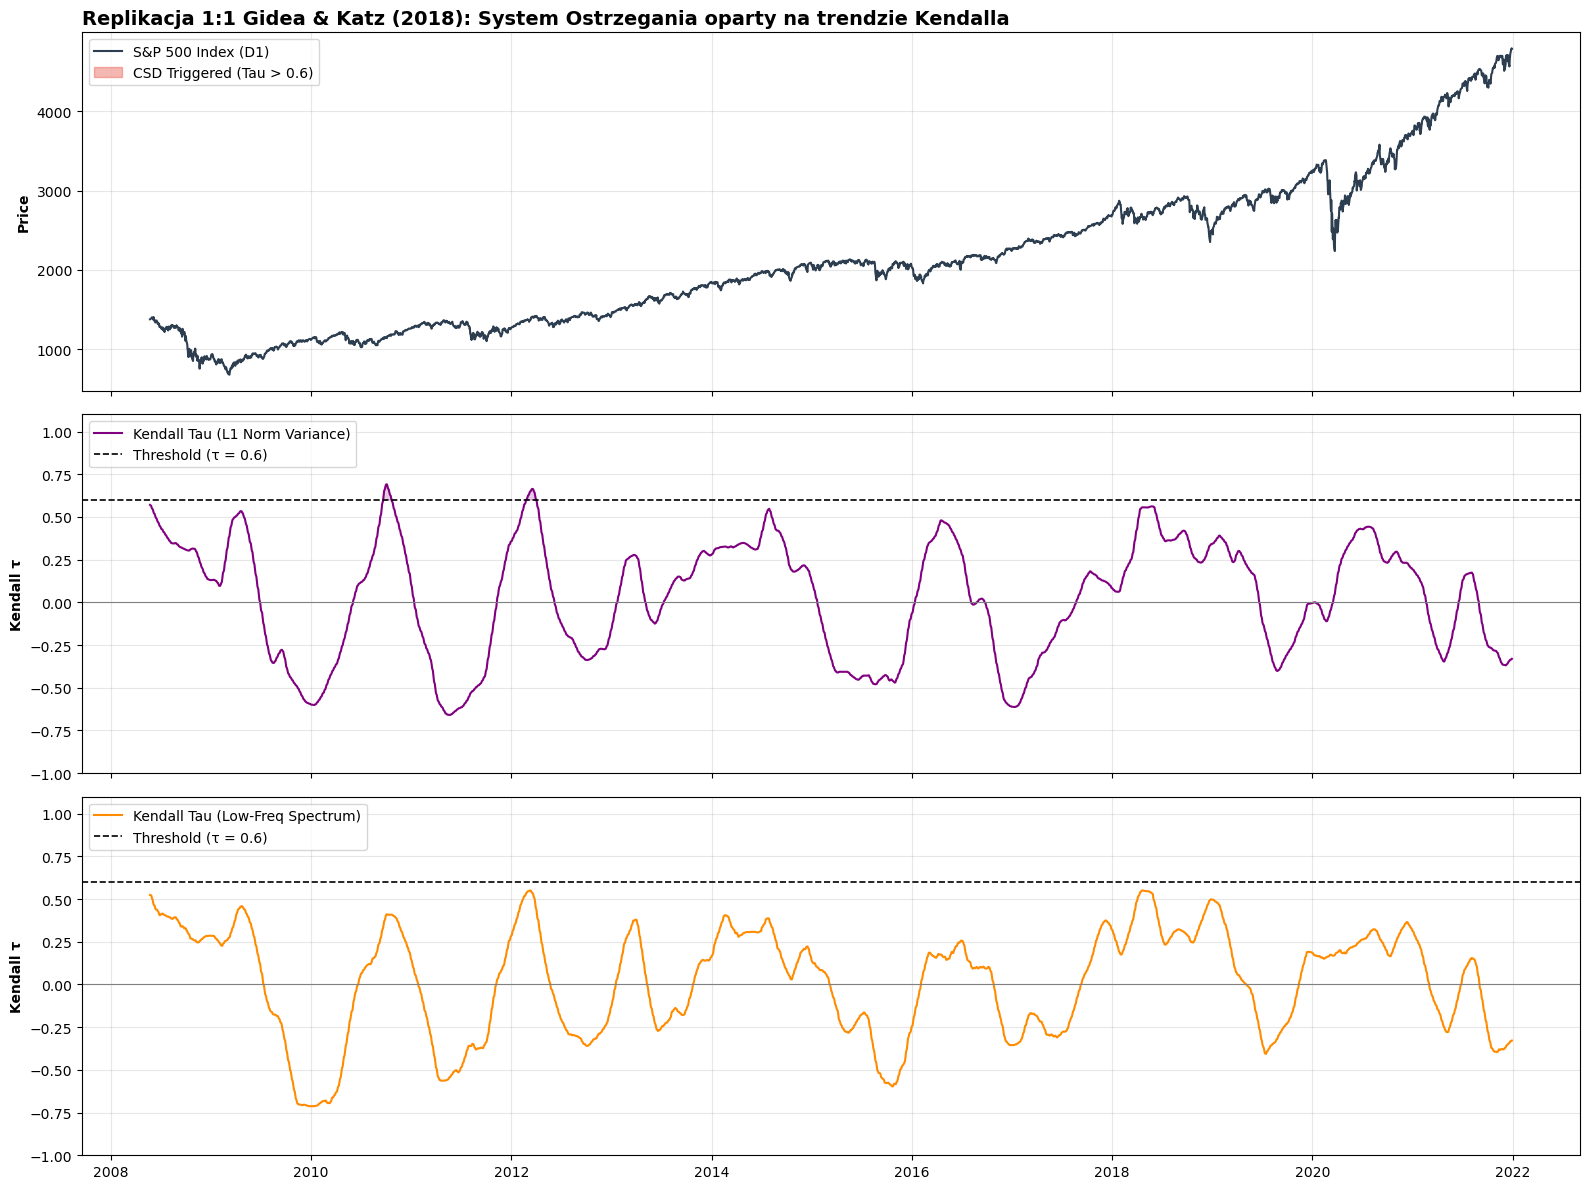

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import yfinance as yf
from scipy.signal import welch
from tqdm import tqdm
from gtda.homology import VietorisRipsPersistence
from gtda.diagrams import PersistenceLandscape
from scipy.stats import kendalltau
import warnings

# ==========================================
# 1. Pobieranie i Przygotowanie Danych (Multi-Asset)
# ==========================================
# ^GSPC = S&P 500, ^DJI = Dow Jones, ^IXIC = NASDAQ, ^RUT = Russell 2000
tickers = ['^GSPC', '^DJI', '^IXIC', '^RUT']
start_date = '2007-01-01'  # Zaczynamy rok wcześniej, żeby mieć bazę pod Z-Score na start 2008
end_date = '2021-12-31'

print("Pobieranie danych z Yahoo Finance...")
df_raw = yf.download(tickers, start=start_date, end=end_date)['Close']

# Obliczanie logarytmicznych stóp zwrotu i czyszczenie danych
df_rets = np.log(df_raw / df_raw.shift(1)).dropna()

# Chmura punktów to po prostu macierz stóp zwrotu (N_dni x 4_indeksy)
# Każdy dzień to punkt w R^4
data_matrix = df_rets.values
dates_vector = df_rets.index

# ==========================================
# 2. Topologiczna Ekstrakcja Cech (Okno kroczące w R^4)
# ==========================================
# w_size = 60       # Okno ok. 3 miesięcy handlowych (Gidea & Katz używali krótszych okien dla danych D1)
w_size = 50       # Okno ok. 3 miesięcy handlowych (Gidea & Katz używali krótszych okien dla danych D1)

eval_step = 1     # Przy danych dziennych możemy liczyć dzień po dniu (brak luku informacyjnego)

VR = VietorisRipsPersistence(homology_dimensions=[1], n_jobs=-1)
landscape = PersistenceLandscape(n_bins=100, n_layers=1)

n_windows = len(data_matrix) - w_size
landscape_norms = []
window_dates = []

print(f"Uruchamianie wielowymiarowego pipeline TDA (Okno={w_size} dni)...")
for i in tqdm(range(0, n_windows, eval_step)):
    # Wycinamy okno czasowe zawierające punkty z 4 indeksów simultanicznie
    window_data = data_matrix[i : i + w_size]  # Kształt: (w_size, 4)
    
    # TDA na naturalnej chmurze punktów
    diagrams = VR.fit_transform([window_data])
    raw_diagram = diagrams[0]
    
    # Zabezpieczenie przed pustym diagramem
    dummy_h1 = np.array([[0.0, 0.0, 1]])
    safe_diagram = dummy_h1 if raw_diagram.size == 0 else np.vstack((raw_diagram, dummy_h1))
    
    # Krajobraz persystentny i norma L1
    landscapes_arrays = landscape.fit_transform(np.array([safe_diagram]))
    l1_norm = np.sum(np.abs(landscapes_arrays[0, 0, :]))
    
    landscape_norms.append(l1_norm)
    window_dates.append(dates_vector[i + w_size - 1])

norms_series = pd.Series(landscape_norms, index=window_dates)

# S&P 500 jako indeks referencyjny do wykresu ceny
spy_price = df_raw['^GSPC'].loc[norms_series.index]


# Ignorujemy ostrzeżenia o pustych oknach (częste przy początkowych obliczeniach okien kroczących)
warnings.filterwarnings('ignore')

# ==========================================
# 3. Zgodne z Gidea & Katz: CSD & Kendall's Tau
# ==========================================
var_window = 50      # Okno do liczenia wariancji z normy L1 (np. 50 dni handlowych)
tau_window = 252     # Okno badania trendu: 1 rok (szukamy powolnego narastania napięć)

print("Obliczanie miar Critical Slowing Down (Wariancja i Spektrum)...")
# 1. Wariancja krocząca normy L1
rolling_variance = norms_series.rolling(window=var_window).var()

# 2. Spektrum niskich częstotliwości z normy L1
def low_freq_spectral_density(window_data):
    valid_data = window_data[~np.isnan(window_data)]
    if len(valid_data) < 20: 
        return np.nan
    freqs, psd = welch(valid_data, nperseg=15)
    low_freq_mask = freqs < np.percentile(freqs, 30)
    return np.mean(psd[low_freq_mask])

rolling_spectrum = norms_series.rolling(window=var_window).apply(low_freq_spectral_density, raw=True)

# 3. KROCZĄCA KORELACJA TAU KENDALLA (Serce algorytmu autorów)
def calculate_kendall_tau(window_data):
    """
    Liczy korelację między wartością wskaźnika a czasem. 
    Wartość bliska +1.0 oznacza stały, nieprzerwany trend rosnący.
    """
    valid_data = window_data[~np.isnan(window_data)]
    if len(valid_data) < tau_window // 2:  # Zabezpieczenie przed pustym oknem
        return np.nan
    
    # Wektor czasu: [0, 1, 2, ..., N]
    time_vector = np.arange(len(valid_data))
    
    # Liczymy tau Kendalla i ignorujemy p-value (drugi argument)
    tau, _ = kendalltau(time_vector, valid_data)
    return tau

print(f"Obliczanie trendu Kendalla (Okno = {tau_window} dni). To może zająć kilka sekund...")
tau_var = rolling_variance.rolling(window=tau_window).apply(calculate_kendall_tau, raw=True)
tau_spec = rolling_spectrum.rolling(window=tau_window).apply(calculate_kendall_tau, raw=True)

# 4. Definicja Alarmu Gidei-Katza
# Według CSD wariancja i spektrum muszą stale rosnąć przed punktem krytycznym.
# Ustalamy próg tau = 0.6 (silny trend wzrostowy).
TAU_THRESHOLD = 0.60
composite_alarm = (tau_var > TAU_THRESHOLD) & (tau_spec > TAU_THRESHOLD)

# ==========================================
# 4. Wizualizacja (Automatyczna synchronizacja DataFrame)
# ==========================================
df_plot = pd.DataFrame({
    'price': spy_price,
    'tau_var': tau_var,
    'tau_spec': tau_spec,
    'alarm': composite_alarm
})

# Odcinamy rozgrzewkę (pierwsze lata, gdzie brakuje danych do pełnego okna tau)
df_plot = df_plot.loc['2008-01-01':'2021-12-31'].dropna()

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
color_alarm = '#e74c3c'

# Panel 1: S&P 500 z Nakładką Alarmów
ax1.plot(df_plot.index, df_plot['price'].values, color='#2c3e50', linewidth=1.5, label='S&P 500 Index (D1)')
ax1.fill_between(df_plot.index, df_plot['price'].min(), df_plot['price'].max(),
                 where=df_plot['alarm'].values, color=color_alarm, alpha=0.4, label=f'CSD Triggered (Tau > {TAU_THRESHOLD})')
ax1.set_ylabel('Price', fontweight='bold')
ax1.set_title('Replikacja 1:1 Gidea & Katz (2018): System Ostrzegania oparty na trendzie Kendalla', loc='left', fontweight='bold', fontsize=14)
ax1.legend(loc='upper left')
ax1.grid(alpha=0.3)

# Panel 2: Kendall's Tau dla Wariancji Normy L1
ax2.plot(df_plot.index, df_plot['tau_var'].values, color='purple', linewidth=1.5, label='Kendall Tau (L1 Norm Variance)')
ax2.axhline(y=TAU_THRESHOLD, color='black', linestyle='--', linewidth=1.2, label=f'Threshold (τ = {TAU_THRESHOLD})')
ax2.axhline(y=0, color='gray', linestyle='-', linewidth=0.8)
ax2.fill_between(df_plot.index, df_plot['tau_var'].values, TAU_THRESHOLD, where=(df_plot['tau_var'].values > TAU_THRESHOLD), color='purple', alpha=0.2)
ax2.set_ylabel('Kendall τ', fontweight='bold')
ax2.set_ylim(-1, 1.1)
ax2.legend(loc='upper left')
ax2.grid(alpha=0.3)

# Panel 3: Kendall's Tau dla Gęstości Spektralnej
ax3.plot(df_plot.index, df_plot['tau_spec'].values, color='darkorange', linewidth=1.5, label='Kendall Tau (Low-Freq Spectrum)')
ax3.axhline(y=TAU_THRESHOLD, color='black', linestyle='--', linewidth=1.2, label=f'Threshold (τ = {TAU_THRESHOLD})')
ax3.axhline(y=0, color='gray', linestyle='-', linewidth=0.8)
ax3.fill_between(df_plot.index, df_plot['tau_spec'].values, TAU_THRESHOLD, where=(df_plot['tau_spec'].values > TAU_THRESHOLD), color='darkorange', alpha=0.2)
ax3.set_ylabel('Kendall τ', fontweight='bold')
ax3.set_ylim(-1, 1.1)
ax3.legend(loc='upper left')
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'gidea_katz_kendall_tau.png', dpi=300)
plt.show()

[*********************100%***********************]  4 of 4 completed


Pobieranie danych z Yahoo Finance...
Uruchamianie wielowymiarowego pipeline TDA (Okno=50 dni)...


100%|██████████| 3725/3725 [01:01<00:00, 60.98it/s]


1/4: Obliczanie bazowej wariancji i spektrum...
2/4: Obliczanie Causal Z-Score...
3/4: Obliczanie trendu Kendall Tau (to potrwa chwilę)...
4/4: Łączenie wskaźników (Iloczyn Hybrydowy)...


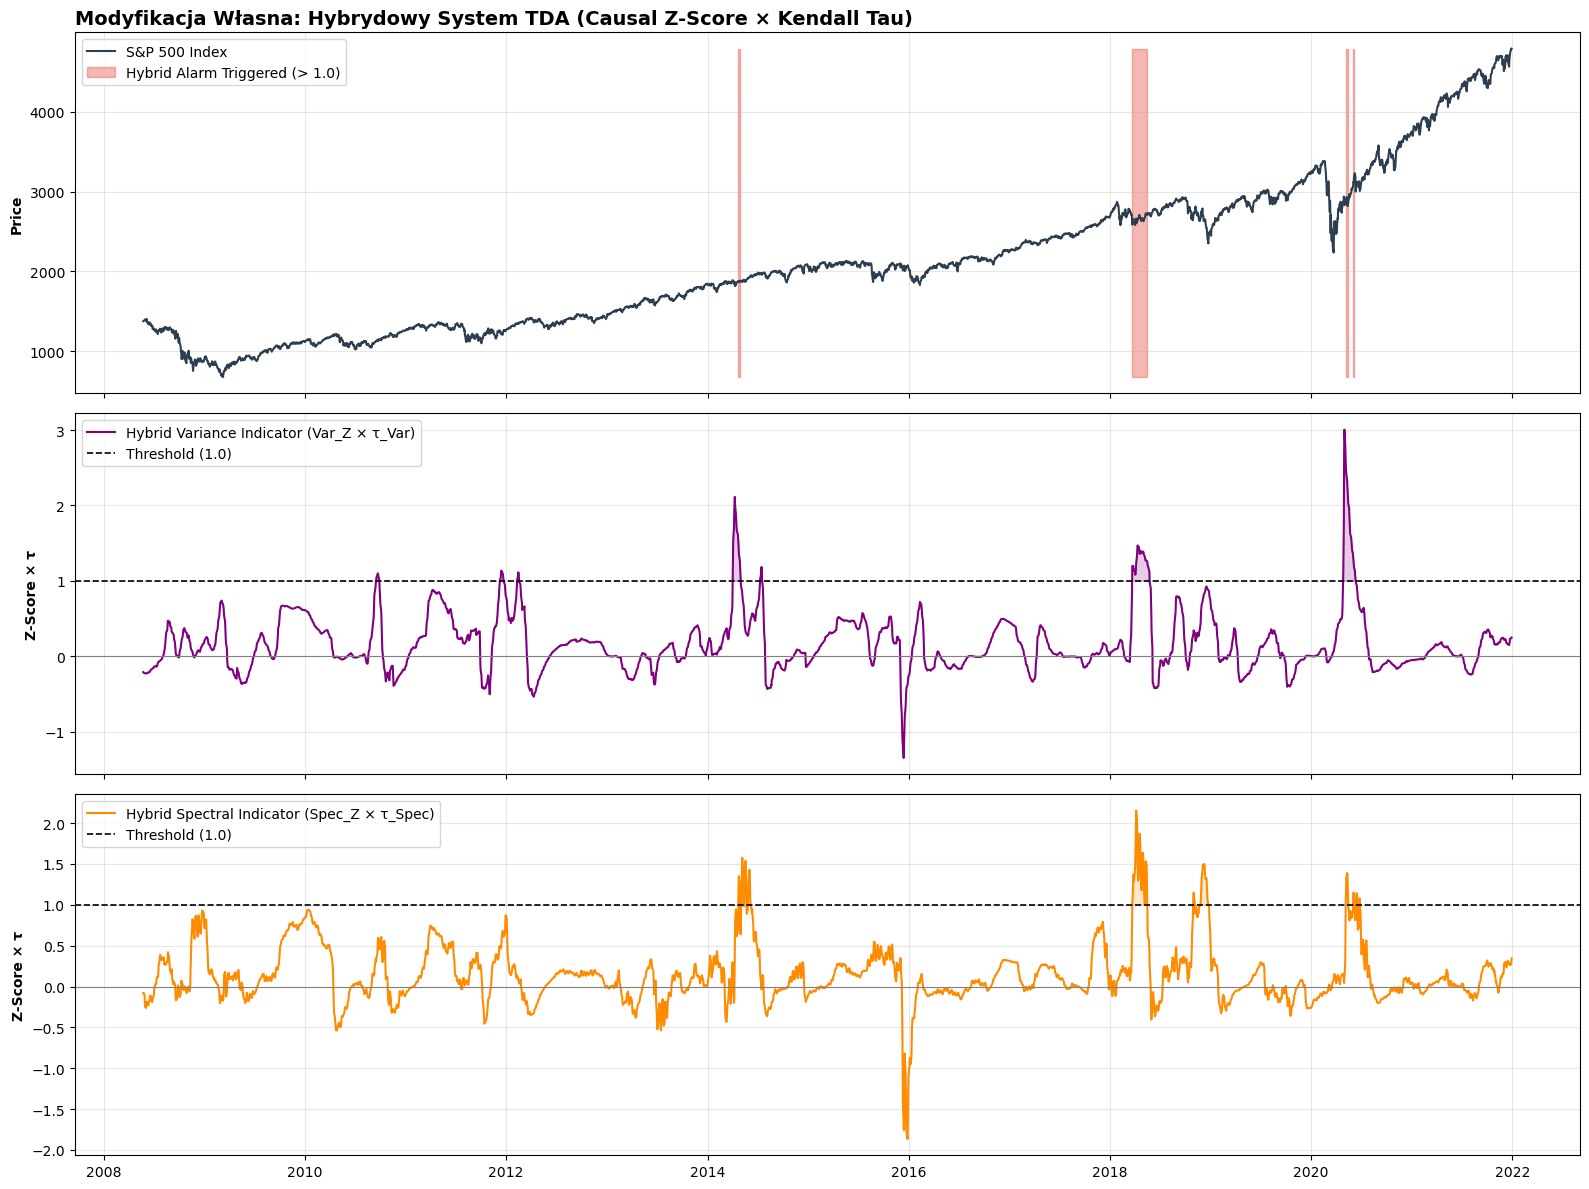

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import yfinance as yf
from scipy.signal import welch
from tqdm import tqdm
from gtda.homology import VietorisRipsPersistence
from gtda.diagrams import PersistenceLandscape
from scipy.stats import kendalltau
import warnings

# ==========================================
# 1. Pobieranie i Przygotowanie Danych (Multi-Asset)
# ==========================================
# ^GSPC = S&P 500, ^DJI = Dow Jones, ^IXIC = NASDAQ, ^RUT = Russell 2000
tickers = ['^GSPC', '^DJI', '^IXIC', '^RUT']
start_date = '2007-01-01'  # Zaczynamy rok wcześniej, żeby mieć bazę pod Z-Score na start 2008
end_date = '2021-12-31'

print("Pobieranie danych z Yahoo Finance...")
df_raw = yf.download(tickers, start=start_date, end=end_date)['Close']

# Obliczanie logarytmicznych stóp zwrotu i czyszczenie danych
df_rets = np.log(df_raw / df_raw.shift(1)).dropna()

# Chmura punktów to po prostu macierz stóp zwrotu (N_dni x 4_indeksy)
# Każdy dzień to punkt w R^4
data_matrix = df_rets.values
dates_vector = df_rets.index

# ==========================================
# 2. Topologiczna Ekstrakcja Cech (Okno kroczące w R^4)
# ==========================================
# w_size = 60       # Okno ok. 3 miesięcy handlowych (Gidea & Katz używali krótszych okien dla danych D1)
w_size = 50       # Okno ok. 3 miesięcy handlowych (Gidea & Katz używali krótszych okien dla danych D1)

eval_step = 1     # Przy danych dziennych możemy liczyć dzień po dniu (brak luku informacyjnego)

VR = VietorisRipsPersistence(homology_dimensions=[1], n_jobs=-1)
landscape = PersistenceLandscape(n_bins=100, n_layers=1)

n_windows = len(data_matrix) - w_size
landscape_norms = []
window_dates = []

print(f"Uruchamianie wielowymiarowego pipeline TDA (Okno={w_size} dni)...")
for i in tqdm(range(0, n_windows, eval_step)):
    # Wycinamy okno czasowe zawierające punkty z 4 indeksów simultanicznie
    window_data = data_matrix[i : i + w_size]  # Kształt: (w_size, 4)
    
    # TDA na naturalnej chmurze punktów
    diagrams = VR.fit_transform([window_data])
    raw_diagram = diagrams[0]
    
    # Zabezpieczenie przed pustym diagramem
    dummy_h1 = np.array([[0.0, 0.0, 1]])
    safe_diagram = dummy_h1 if raw_diagram.size == 0 else np.vstack((raw_diagram, dummy_h1))
    
    # Krajobraz persystentny i norma L1
    landscapes_arrays = landscape.fit_transform(np.array([safe_diagram]))
    l1_norm = np.sum(np.abs(landscapes_arrays[0, 0, :]))
    
    landscape_norms.append(l1_norm)
    window_dates.append(dates_vector[i + w_size - 1])

norms_series = pd.Series(landscape_norms, index=window_dates)

# S&P 500 jako indeks referencyjny do wykresu ceny
spy_price = df_raw['^GSPC'].loc[norms_series.index]


# Ignorujemy ostrzeżenia o pustych oknach (częste przy początkowych obliczeniach okien kroczących)
warnings.filterwarnings('ignore')

# ==========================================
# 3. Modyfikacja Własna: Hybrydowy Wskaźnik (Z-Score * Kendall Tau)
# ==========================================
var_window = 50        # Okno bazowe dla wariancji/spektrum
z_score_window = 252   # Okno historyczne dla Z-Score (1 rok)
tau_window = 252       # Okno trendu dla Kendalla (1 rok)

print("1/4: Obliczanie bazowej wariancji i spektrum...")
rolling_variance = norms_series.rolling(window=var_window).var()

def low_freq_spectral_density(window_data):
    valid_data = window_data[~np.isnan(window_data)]
    if len(valid_data) < 20: 
        return np.nan
    freqs, psd = welch(valid_data, nperseg=15)
    low_freq_mask = freqs < np.percentile(freqs, 30)
    return np.mean(psd[low_freq_mask])

rolling_spectrum = norms_series.rolling(window=var_window).apply(low_freq_spectral_density, raw=True)

print("2/4: Obliczanie Causal Z-Score...")
# Z-Score dla Wariancji
var_mean = rolling_variance.rolling(window=z_score_window).mean()
var_std = rolling_variance.rolling(window=z_score_window).std()
var_z = (rolling_variance - var_mean) / var_std

# Z-Score dla Spektrum
spec_mean = rolling_spectrum.rolling(window=z_score_window).mean()
spec_std = rolling_spectrum.rolling(window=z_score_window).std()
spec_z = (rolling_spectrum - spec_mean) / spec_std

print("3/4: Obliczanie trendu Kendall Tau (to potrwa chwilę)...")
def calculate_kendall_tau(window_data):
    valid_data = window_data[~np.isnan(window_data)]
    if len(valid_data) < tau_window // 2:
        return np.nan
    time_vector = np.arange(len(valid_data))
    tau, _ = kendalltau(time_vector, valid_data)
    return tau

tau_var = rolling_variance.rolling(window=tau_window).apply(calculate_kendall_tau, raw=True)
tau_spec = rolling_spectrum.rolling(window=tau_window).apply(calculate_kendall_tau, raw=True)

print("4/4: Łączenie wskaźników (Iloczyn Hybrydowy)...")
# PRZEMNAŻAMY JE PRZEZ SIEBIE: Hybrid = Z-Score * Tau
hybrid_var = var_z * tau_var
hybrid_spec = spec_z * tau_spec

# Definicja nowego alarmu hybrydowego
# Szukamy wartości, gdzie iloczyn przekracza próg (np. 1.0)
HYBRID_THRESHOLD = 1.0
composite_alarm = (hybrid_var > HYBRID_THRESHOLD) & (hybrid_spec > HYBRID_THRESHOLD)

# ==========================================
# 4. Wizualizacja Wyników
# ==========================================
df_plot = pd.DataFrame({
    'price': spy_price,
    'hybrid_var': hybrid_var,
    'hybrid_spec': hybrid_spec,
    'alarm': composite_alarm
})

# Odcinamy okres rozgrzewkowy
df_plot = df_plot.loc['2008-01-01':'2021-12-31'].dropna()

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
color_alarm = '#e74c3c'

# Panel 1: S&P 500
ax1.plot(df_plot.index, df_plot['price'].values, color='#2c3e50', linewidth=1.5, label='S&P 500 Index')
ax1.fill_between(df_plot.index, df_plot['price'].min(), df_plot['price'].max(),
                 where=df_plot['alarm'].values, color=color_alarm, alpha=0.4, label=f'Hybrid Alarm Triggered (> {HYBRID_THRESHOLD})')
ax1.set_ylabel('Price', fontweight='bold')
ax1.set_title('Modyfikacja Własna: Hybrydowy System TDA (Causal Z-Score × Kendall Tau)', loc='left', fontweight='bold', fontsize=14)
ax1.legend(loc='upper left')
ax1.grid(alpha=0.3)

# Panel 2: Hybrydowa Wariancja
ax2.plot(df_plot.index, df_plot['hybrid_var'].values, color='purple', linewidth=1.5, label='Hybrid Variance Indicator (Var_Z × τ_Var)')
ax2.axhline(y=HYBRID_THRESHOLD, color='black', linestyle='--', linewidth=1.2, label=f'Threshold ({HYBRID_THRESHOLD})')
ax2.axhline(y=0, color='gray', linestyle='-', linewidth=0.8)
ax2.fill_between(df_plot.index, df_plot['hybrid_var'].values, HYBRID_THRESHOLD, where=(df_plot['hybrid_var'].values > HYBRID_THRESHOLD), color='purple', alpha=0.2)
ax2.set_ylabel('Z-Score × τ', fontweight='bold')
ax2.legend(loc='upper left')
ax2.grid(alpha=0.3)

# Panel 3: Hybrydowe Spektrum
ax3.plot(df_plot.index, df_plot['hybrid_spec'].values, color='darkorange', linewidth=1.5, label='Hybrid Spectral Indicator (Spec_Z × τ_Spec)')
ax3.axhline(y=HYBRID_THRESHOLD, color='black', linestyle='--', linewidth=1.2, label=f'Threshold ({HYBRID_THRESHOLD})')
ax3.axhline(y=0, color='gray', linestyle='-', linewidth=0.8)
ax3.fill_between(df_plot.index, df_plot['hybrid_spec'].values, HYBRID_THRESHOLD, where=(df_plot['hybrid_spec'].values > HYBRID_THRESHOLD), color='darkorange', alpha=0.2)
ax3.set_ylabel('Z-Score × τ', fontweight='bold')
ax3.legend(loc='upper left')
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'gidea_katz_mine.png', dpi=300)
plt.show()